# Compare Vabamorf with homonyms dataset


## Table of contents

1. [**Gathering Data**](#andmete_kogumine)
2. [**Evaluation (BertMorphTaggerV2 vs Vabamorf)**](#hindamine_v2)
3. [**Results BertMorphTaggerV2 vs Vabamorf**](#tulemused_v2)
4. [**Evaluation BertMorphTaggerHomonyms vs Vabamorf**](#hindamine_homonyms)
5. [**Results BertMorphTaggerHomonyms vs Vabamorf**](#tulemused_homonyms)
6. [**Results Baselines**](#tulemused_baseline)

[end](#end)


In [1]:
print("Test")

Test


In [2]:
from pathlib import Path
import sys
import pathlib

# Add the project's root directory to the Python path
sys.path.append(pathlib.Path("../").resolve().as_posix())

import os
import json
import warnings
import types
import evaluate
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn

import matplotlib.pyplot as plt
import seaborn as sns

# from bert_morph_tagger_notebook_functions import NotebookFunctions

# from simpletransformers.ner import NERModel, NERArgs
from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from estnltk.converters.label_studio.labelling_configurations import (
    PhraseClassificationConfiguration,
)
from estnltk.converters.label_studio.labelling_tasks import PhraseClassificationTask

e:\Git_projects\EstNLTK\simpletransformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
poseval = evaluate.load("evaluate-metric/poseval", module_type="metric")


def custom_metrics(preds, labels):

    # Evaluate using poseval
    result = poseval.compute(predictions=preds, references=labels, zero_division=0)

    return result

<a id='andmete_kogumine'></a>


### Gathering data


In [4]:
# Use specific annotation configurations that were used in homonyms dataset
annotation_confs = {
    1: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g -- ainsuse omastav):",
        header_placement="middle",
    ),
    16: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g -- ainsuse omastav):",
        header_placement="middle",
    ),
    17: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg n": "sg n", "sg g": "sg g", "sg p": "sg p"},
        header="Vali sõna morfoloogiline vorm (sg n - ainsuse nimetav, sg g - ainsuse omastav, sg p - ainsuse osastav):",
        header_placement="middle",
    ),
    19: PhraseClassificationConfiguration(
        phrase_labels=["analüüsitav sõna"],
        class_labels={"sg g": "sg g", "sg p": "sg p", "adt": "adt"},
        header="Vali sõna morfoloogiline vorm (sg g - ainsuse omastav, sg p - ainsuse osastav, adt - lühike sisseütlev):",
        header_placement="middle",
    ),
}

In [ ]:
# Collect input files
input_files = []
input_dir = "../data/homonymous_word_forms/annotations/"
for fname in os.listdir(input_dir):
    if os.path.isdir(os.path.join(input_dir, fname)):
        for subfname in os.listdir(os.path.join(input_dir, fname)):
            if subfname.endswith(".json"):
                inflection_type = int(subfname.split("_")[2])  # infl_type_xx_1000_vx...
                input_files.append(
                    (
                        inflection_type,
                        "../data/homonymous_word_forms/annotations/"
                        + fname
                        + "/"
                        + subfname,
                    )
                )

if not input_files:
    raise RuntimeError("No input files found!")

print(f"Found {len(input_files)} input files.")

Found 8 input files.


In [ ]:
overall_data = []
# Extract data from input files
for infl_type, input_file in input_files:
    print(f"Processing file: {input_file} (inflection type {infl_type})")
    num = input_file.split("/")[3]
    annotation_conf = annotation_confs[infl_type]
    with open(input_file, "r", encoding="utf-8") as f:
        raw = f.read()
    task = PhraseClassificationTask(
        annotation_conf,
        input_layer="morph",
        output_layer="morph",
        label_attribute="label",
    )
    classified_sentences = task.import_data(raw)

    # Create dataframe from classified sentences
    data = []
    for sentence in classified_sentences:
        for annotation in sentence.morph:
            if (
                "class_label" in sentence.meta
                and sentence.meta["class_label"] is not None
            ):
                data.append(
                    {
                        "num": num,
                        "inflection_type": infl_type,
                        "sentence": sentence.text,
                        "word": annotation.text,
                        "word_span": (annotation.start, annotation.end),
                        "label": sentence.meta["class_label"],
                    }
                )
    df = pd.DataFrame(data)
    output_csv = f"../data/homonymous_word_forms/processed/homonyms_infltype_{num}_{infl_type}.csv"
    df.to_csv(output_csv, index=False)
    print(f"Saved processed data to {output_csv}")
    overall_data.extend(data)

# Create overall dataframe
overall_df = pd.DataFrame(overall_data)
overall_output_csv = "../data/homonymous_word_forms/processed/homonyms_overall.csv"
overall_df.to_csv(overall_output_csv, index=False)
print(f"Saved overall processed data to {overall_output_csv}")

Processing file: ./homonymous_word_forms/annotations/1/infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json (inflection type 1)
Saved processed data to ./homonymous_word_forms/processed/homonyms_infltype_1_1.csv
Processing file: ./homonymous_word_forms/annotations/1/infl_type_16_1000_v1_project-2-at-2024-11-21-19-27-9e8ae0c2.json (inflection type 16)
Saved processed data to ./homonymous_word_forms/processed/homonyms_infltype_1_16.csv
Processing file: ./homonymous_word_forms/annotations/1/infl_type_17_1000_v1.json (inflection type 17)
Saved processed data to ./homonymous_word_forms/processed/homonyms_infltype_1_17.csv
Processing file: ./homonymous_word_forms/annotations/1/infl_type_19_1000_v1_project-6-at-2025-11-15-14-13-42753676.json (inflection type 19)
Saved processed data to ./homonymous_word_forms/processed/homonyms_infltype_1_19.csv
Processing file: ./homonymous_word_forms/annotations/2/infl_type_01_1000_v2_project-5-at-2024-12-11-21-53-280753b4.json (inflection type 

<a id='hindamineV2'></a>


### Evaluation (BertMorphTaggerV2 vs Vabamorf)


In [14]:
# import importlib
# import scripts.model.bert_morph_tagger as bmt_module

# importlib.reload(bmt_module)
# BertMorphTagger = bmt_module.BertMorphTagger

In [15]:
from estnltk.default_resolver import make_resolver

# Load BertMorphTagger model
bmt_model_name = "../models/NER_mudel_v2/"
bmt_model = BertMorphTagger(model_location=str(bmt_model_name))

# Load default resolver
resolver = make_resolver()

In [16]:
overall_df = pd.read_csv("../data/homonymous_word_forms/processed/homonyms_overall.csv")

In [17]:
overall_df.groupby(["inflection_type", "label"]).size().reset_index().sort_values(
    by="inflection_type"
)

,inflection_type,label,0
0,1,['sg g'],1232
1,1,['sg n'],764
2,16,['sg g'],1080
3,16,['sg n'],890
4,17,['sg g'],524
5,17,['sg n'],791
6,17,['sg p'],609
7,19,['adt'],94
8,19,['sg g'],1621
9,19,['sg p'],281


In [18]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",['sg n']
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",['sg n']
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",['sg n']
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",['sg n']
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",['sg g']


In [19]:
outer = tqdm(
    overall_df.iterrows(),
    total=len(overall_df),
    desc="Evaluating BertMorphTaggerHomonym vs Vabamorf",
)


# Evaluate BertMorphTaggerHomonym vs Vabamorf
results = []
for index, row in outer:
    sentence_text = row["sentence"]
    num = row["num"]
    inflection_type = row["inflection_type"]
    word_to_analyze = row["word"]
    word_span = row["word_span"]
    true_label = row["label"][2:-2]  # Remove "['" and "']" from the label string

    # Create EstNLTK Text object
    text = estnltk.Text(sentence_text)
    text.tag_layer("sentences")

    # Apply BertMorphTagger
    bmt_model.tag(text)

    # Get BertMorphTagger prediction for the word
    # in the new bert_morph_tagging layer
    bmt_prediction = None
    for annotation in text.bert_morph_tagging:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            bmt_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(bmt_prediction, list):
                bmt_prediction = bmt_prediction[0]

    # Apply Vabamorf
    text.tag_layer(resolver=resolver)

    # Get Vabamorf prediction for the word
    vabamorf_prediction = None
    for annotation in text.morph_analysis:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            vabamorf_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(vabamorf_prediction, list):
                vabamorf_prediction = vabamorf_prediction[0]

    results.append(
        {
            "num": num,
            "inflection_type": inflection_type,
            "sentence": sentence_text,
            "word": word_to_analyze,
            "true_label": true_label,
            "bmt_prediction": bmt_prediction,
            "vabamorf_prediction": vabamorf_prediction,
        }
    )
    outer.refresh()

# Create results dataframe
results_df = pd.DataFrame(results)
results_output_csv = (
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results_v2.csv"
)
results_df.to_csv(results_output_csv, index=False)

Evaluating BertMorphTaggerHomonym vs Vabamorf:   6%|▌         | 459/7886 [00:27<07:31, 16.44it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:228: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': 'r', 'form': 'sg n', 'partofspeech': 'A', 'probability': 0.9998}]).
  warnings.warn(
Evaluating BertMorphTaggerHomonym vs Vabamorf:  35%|███▌      | 2769/7886 [02:35<04:38, 18.35it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:228: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': ',', 'form': '', 'partofspeech': 'Z', 'probability': 0.99999}]).
  warnings.warn(
Evaluating BertMorphTaggerHomonym vs Vabamorf:  43%|████▎     | 3401/7886 [03:11<03:43, 20.05it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:228: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens

In [21]:
display(results_df.head())

,num,inflection_type,sentence,word,true_label,bmt_prediction,vabamorf_prediction
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,sg n,sg n,sg n
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,sg n,sg n,sg n
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,sg n,sg n,sg n
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,sg n,sg n,sg n
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,sg g,sg g,sg g


<a id='tulemused_v2'></a>


### Results BertMorphTaggerV2 vs Vabamorf


In [22]:
# Load results dataframe
results_df = pd.read_csv(
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results_v2.csv",
    index_col=False,
)

# Fill NaN predictions with "no_prediction"
results_df["bmt_prediction"] = results_df["bmt_prediction"].fillna("no_prediction")
results_df["vabamorf_prediction"] = results_df["vabamorf_prediction"].fillna(
    "no_prediction"
)

# Generate confusion matrices for both models
bmt_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["bmt_prediction"]
)

vabamorf_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["vabamorf_prediction"]
)

# Generate classification reports for both models
bmt_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["bmt_prediction"],
    zero_division=0,
)

vabamorf_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["vabamorf_prediction"],
    zero_division=0,
)

# # flat lists (one label per sentence)
# preds = results_df["bmt_prediction"].tolist()
# refs = results_df["true_label"].tolist()

# # convert to list-of-lists where each inner list is the token sequence for one sentence
# preds_grouped = [[p] for p in preds]
# refs_grouped = [[r] for r in refs]

# # sanity checks
# assert len(preds_grouped) == len(refs_grouped)
# for p, r in zip(preds_grouped, refs_grouped):
#     assert len(p) == len(r)  # should be 1 for your case

# # Call poseval
# results = poseval.compute(predictions=preds_grouped, references=refs_grouped)
# # Print weighted average metrics as percentages
# print(f"Accuracy: \t{results['accuracy']:.2%}")
# print(f"Precision: \t{results['weighted avg']['precision']:.2%}")
# print(f"Recall: \t{results['weighted avg']['recall']:.2%}")
# print(f"F1-score: \t{results['weighted avg']['f1-score']:.2%}")

In [23]:
# Print classification reports
print("Overall Evaluation Results:")
print("BertMorphTagger Classification Report:")
print(bmt_results_cr)
print("Vabamorf Classification Report:")
print(vabamorf_results_cr)

Overall Evaluation Results:
BertMorphTagger Classification Report:
               precision    recall  f1-score   support

          adt       0.96      0.74      0.84        94
           me       0.00      0.00      0.00         0
no_prediction       0.00      0.00      0.00         0
            o       0.00      0.00      0.00         0
         pl g       0.00      0.00      0.00         0
         pl n       0.00      0.00      0.00         0
         pl p       0.00      0.00      0.00         0
        sg el       0.00      0.00      0.00         0
         sg g       0.96      0.98      0.97      4457
         sg n       0.96      0.91      0.94      2445
         sg p       0.90      0.90      0.90       890

     accuracy                           0.95      7886
    macro avg       0.34      0.32      0.33      7886
 weighted avg       0.95      0.95      0.95      7886

Vabamorf Classification Report:
              precision    recall  f1-score   support

         adt      

In [24]:
# Print classification reports
print("Overall Evaluation Results:")
print("BertMorphTagger Classification Report:")
print(bmt_results_cr)
print("Vabamorf Classification Report:")
print(vabamorf_results_cr)

Overall Evaluation Results:
BertMorphTagger Classification Report:
               precision    recall  f1-score   support

            ?       0.00      0.00      0.00         0
          adt       0.66      0.35      0.46        94
           da       0.00      0.00      0.00         0
           ge       0.00      0.00      0.00         0
           ma       0.00      0.00      0.00         0
           me       0.00      0.00      0.00         0
        neg o       0.00      0.00      0.00         0
no_prediction       0.00      0.00      0.00         0
            o       0.00      0.00      0.00         0
         pl g       0.00      0.00      0.00         0
         pl n       0.00      0.00      0.00         0
         pl p       0.00      0.00      0.00         0
            s       0.00      0.00      0.00         0
       sg all       0.00      0.00      0.00         0
        sg el       0.00      0.00      0.00         0
        sg es       0.00      0.00      0.00        

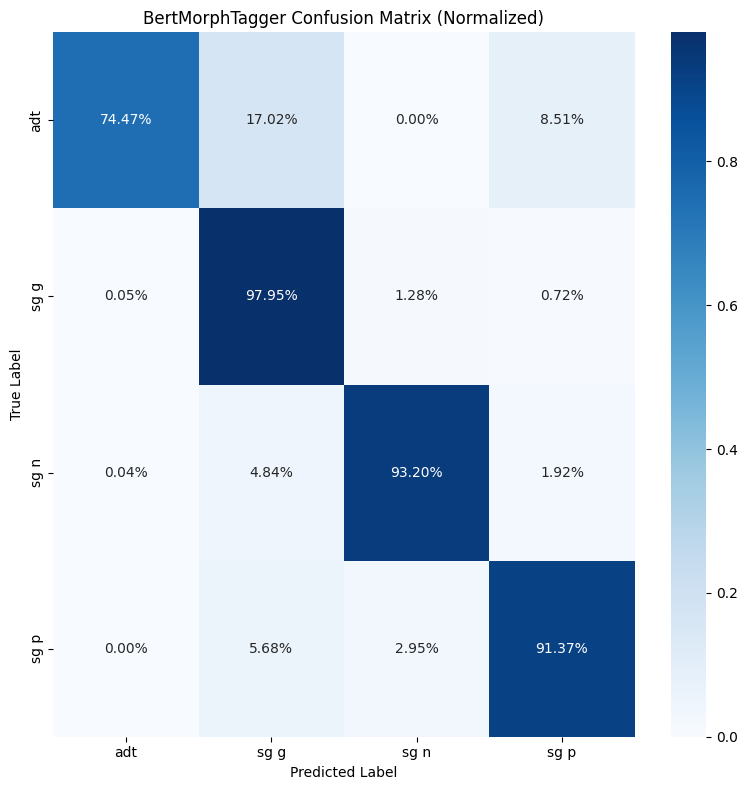

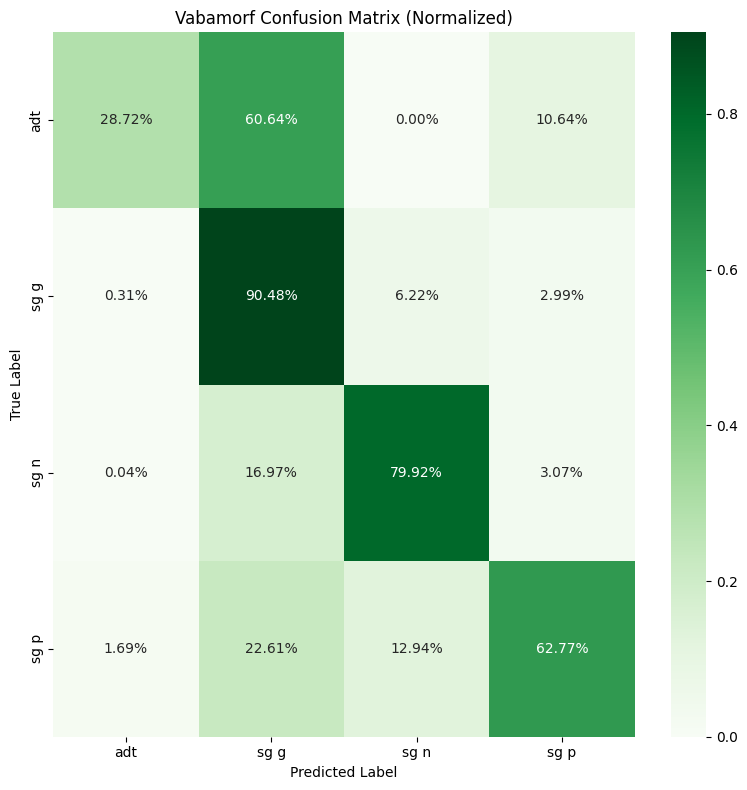

In [27]:
# Remove predictions that are not in the true labels for better visualization
bmt_cm_filtered = bmt_cm[
    np.isin(
        np.unique(results_df["bmt_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["bmt_prediction"]), np.unique(results_df["true_label"])
    ),
]

vabamorf_cm_filtered = vabamorf_cm[
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    ),
]

# Plot confusion matrix for BertMorphTagger with percentage values
plt.figure(figsize=(8, 8))
bmt_cm_normalized = (
    bmt_cm_filtered.astype("float") / bmt_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    bmt_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("BertMorphTagger Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/v2/BertMorphTaggerCM", dpi=300)
plt.show()

# Plot confusion matrix for Vabamorf with percentage values
plt.figure(figsize=(8, 8))
vabamorf_cm_normalized = (
    vabamorf_cm_filtered.astype("float")
    / vabamorf_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    vabamorf_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("Vabamorf Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/v2/VabamorfCM", dpi=300)
plt.show()

In [29]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "adt"
sg_g_as_adt = results_df[
    (results_df["bmt_prediction"] == "sg g") & (results_df["true_label"] == "adt")
]
print(sg_g_as_adt["inflection_type"].value_counts())
print(sg_g_as_adt["word"].value_counts().head(5))
display(sg_g_as_adt)
# Analyse results where BertMorphTagger predicted "sg p", but the true label was "adt"
sg_p_as_adt = results_df[
    (results_df["bmt_prediction"] == "sg p") & (results_df["true_label"] == "adt")
]
print(sg_p_as_adt["inflection_type"].value_counts())
print(sg_p_as_adt["word"].value_counts().head(5))
display(sg_p_as_adt)

inflection_type
19    16
Name: count, dtype: int64
word
mikrofoni      2
gümnaasiumi    2
restorani      2
muuseumi       2
Washingtoni    1
Name: count, dtype: int64


,num,inflection_type,sentence,word,true_label,bmt_prediction,vabamorf_prediction
3002,1,19,"""Ühe Euroopa sõidu ajal, kui arvati, et see idarahvas on natuke rumal, ja taheti presidendile tõlki, ütles Meri mikrofoni inglise keeles, et tal on vaja küsimusi, mitte tõlki!"" lausub 7. klassi poiss Tõnis.",mikrofoni,adt,sg g,sg g
3013,1,19,"Samas on kõik uue kodu lähistel asuvad koolid sellised, mis võtavad gümnaasiumi vastu katsetega.",gümnaasiumi,adt,sg g,sg g
3248,1,19,Kolkjasse Kala-Sibula restorani jõudmiseks kulub tallinlasel umbes kolm ja pool tundi.,restorani,adt,sg g,sg g
3497,1,19,Hiljem tuleb tunnussõnaga numbri valimiseks vajutada aparaadi küljel olevale nupule ning öelda aparaadi või hands-free mikrofoni tunnussõna ning telefon valibki soovitava numbri.,mikrofoni,adt,sg g,sg g
3527,1,19,Ajalehe Ha'aretz teatel sõidab Peres Cairosse neljapäeval enne järgmise nädala visiiti Washingtoni kõnelustele USA välisministri Colin Powelliga.,Washingtoni,adt,sg g,sg g
3532,1,19,"Moskva teatas kavatusest 540 km pikkune piir sulgeda läinud nädalal, reageerides sellega tshetsheeni islamivõitlejate tungimisele üle piiri Dagestani ja pommiplahvatustele Venemaal.",Dagestani,adt,sg g,sg g
3550,1,19,"Tagantjärelegi on tal raske mõista, miks võtsid professoritest vangid leedulane Kezgailo ja lätlane Ošins endale suure riski : kui neil tekkis võimalus võtta haigla personali lisaks üks meditsiinitöötaja, valisid nad Laane.",personali,adt,sg g,sg g
3572,1,19,"Warner Bros lükkas oktoobrist veebruari uue Arnold Schwarzeneggeri filmi ""Kaasnevad purustused"" (Collateral damage) esilinastuse, sest seal on juttu õhkulastud pilvelõhkujast.",veebruari,adt,sg g,sg g
3763,1,19,"Raha, sõjatehnika ja instruktorid lähevad Indoneesiasse, Usbekistani, Nepali, Jordaaniasse, Pakistani, Kasahstani, Kõrgõzstani ja Usbekistani, kinnitas kaitseministeeriumi esindaja.",Usbekistani,adt,sg g,adt
3823,1,19,"Pärast viimast sõda asus ta tööle Tallinna, alul loodusteaduste muuseumi, hiljem töötas Õpetajate Täiendusinstituudis ja Tallinna Pedagoogilises Instituudis.",muuseumi,adt,sg g,sg g


inflection_type
19    8
Name: count, dtype: int64
word
restorani    2
alkoholi     2
telefoni     1
terminali    1
tribunali    1
Name: count, dtype: int64


,num,inflection_type,sentence,word,true_label,bmt_prediction,vabamorf_prediction
2981,1,19,"Pealinna tänavail ringi uidates tungisid neist kolm restorani, kus lükkasid ümber laudu ja toole ning mugisid porgandeid.",restorani,adt,sg p,sg p
3113,1,19,"Ameerika ülikoolid püüavad kaitsta verisulis elluastujaid alkoholi uppumast, Eesti kõrgkoolid seni mitte",alkoholi,adt,sg p,sg p
3921,1,19,"""Eesti alkoholi suhtutakse üldiselt üleolevalt,"" räägib Tschakkar, ""tavaliselt võetakse pidudele ükskõik mis jooki, peaasi, et välismaine.",alkoholi,adt,sg p,sg g
7088,2,19,"Või läheks hiina restorani sööma, härra Allikmaa?",restorani,adt,sg p,sg g
7456,2,19,Väga ilusasti ütles see daam telefoni.,telefoni,adt,sg p,sg p
7664,2,19,Foto : Rauno Volmar Estonian Air hakkab alates 25. märtsist lendama Pariisi Charles de Gaulle'i lennujaama terminali 1 senise terminali 2B asemel.,terminali,adt,sg p,sg g
7808,2,19,"Lõoke olevat öelnud, et ""kõik kommunistid tuleb hävitada"", seda pandi talle süüks ning kõik kätte saadud rakkelastest omakaitselased toodi tribunali tunnistama.",tribunali,adt,sg p,sg g
7874,2,19,"""Pidage rangelt kinni raportiteks ette nähtud kellaaegadest!"" kõmistas ta mikrofoni, ise samal ajal ""külalistetoas"" temperatuuri tõstes.",mikrofoni,adt,sg p,adt


BertMorphTaggerV2 pakub lühikese sisseütleva (`adt`) asemel omastava (`sg g`), osastava (`sg p`) või nimetava (`sg n`) käände vormi. Kõik näited on muuttüübist 19.


In [31]:
# Analyse results where BertMorphTagger predicted "sg n", but the true label was "sg g"
sg_n_as_sg_g = results_df[
    (results_df["bmt_prediction"] == "sg n") & (results_df["true_label"] == "sg g")
]
print(sg_n_as_sg_g["inflection_type"].value_counts())
print(sg_n_as_sg_g["word"].value_counts().head(5))
display(sg_n_as_sg_g)
# Analyse results where BertMorphTagger predicted "sg p", but the true label was "sg g"
sg_p_as_sg_g = results_df[
    (results_df["bmt_prediction"] == "sg p") & (results_df["true_label"] == "sg g")
]
print(sg_p_as_sg_g["inflection_type"].value_counts())
print(sg_p_as_sg_g["word"].value_counts().head(5))
display(sg_p_as_sg_g)

inflection_type
16    28
1     26
17     2
19     1
Name: count, dtype: int64
word
Saku          5
korraldaja    2
aasta         2
juhataja      1
võitja        1
Name: count, dtype: int64


,num,inflection_type,sentence,word,true_label,bmt_prediction,vabamorf_prediction
38,1,1,Andres Ülviste Paetisme - Pühapäeval läheb Eesti suveajale.,Ülviste,sg g,sg n,sg n
103,1,1,56 spordiajakirjanikku 36 riigist valisid aasta spordiisiksuseks tänavuse Tour de France'i võitja Lance Armstrongi (USA).,võitja,sg g,sg n,sg g
178,1,1,Võrumaa veterinaarkeskuse juhataja Neeme Truija arvates jääb neid tõenäoliselt alles kaks.,juhataja,sg g,sg n,sg n
384,1,1,Halinga Puu raamatupidamises ei kajastu ka H & N Finantseerimisgrupi 264 386 dollari suurune nõue.,Halinga,sg g,sg n,sg g
498,1,1,"Eks Kaubamaja kaubamärgiga opereerirva AS-i Veneetsia Kaupmees omaniku Eesti Talleksi juhataja Ivar Simson ütles, et Eks Kaubamaja kavatseb likviiduskriisist üle saada kaubavarude mahamüümisega.",Veneetsia,sg g,sg n,sg g
516,1,1,"Tallinna, Tartu, Pärnu ja mõned muud on juba käes.",Tartu,sg g,sg n,sg g
642,1,1,Ürituse korraldaja Merle Ljubimova sõnul võivad mõned jalutuskäiketenduse stseenid libahuntide ja kummitustega publikut ehmatadagi.,korraldaja,sg g,sg n,sg g
834,1,1,EPMÜ avalikkussuhete korraldaja Katrin Uindi sõnul suurt tseremooniat ei korraldata.,korraldaja,sg g,sg n,sg g
869,1,1,Jäähokiliigas NHL alistas Ottawa Senators 4 : 1 Colorado Avalanche.,Ottawa,sg g,sg n,sg n
1024,1,16,"Heati esitosinasse avamängus Atlanta Hawksi vastu valiti tagamängijad Tim Hardaway, Sasha Danilovic, Dan Majerle, Voshon Lenard, Gary Grant, ründajad Kurt Thomas, Keith Askins, Mark Strickland, Ed Pinckney, keskmängijad Alonzo Mourning, P.J Brown ja Isaac Austin.",Atlanta,sg g,sg n,sg g


inflection_type
17    22
19     7
16     3
Name: count, dtype: int64
word
elu      4
raha     4
kahju    3
vaba     2
osa      2
Name: count, dtype: int64


,num,inflection_type,sentence,word,true_label,bmt_prediction,vabamorf_prediction
1317,1,16,"Aastatel 1999-2002 vargustega kokku 4,2 miljonit krooni kahju tekitanud jõugu käekiri oli robustne.",kahju,sg g,sg p,sg p
1799,1,16,Ringkonnakohtu 12. novembri otsuse järgi peab Tartu linnavalitsus kannatanuks osutunud naisterahvale hüvitama talvises avariis sõiduautole Jaguar tekkinud kahju.,kahju,sg g,sg p,sg p
2064,1,17,"Teine neiu soovib kaitseväelase elu läbi teha selleks, et hiljem asuda õppima Riigikaitse Akadeemiasse, rääkis Seppik.",elu,sg g,sg p,sg n
2206,1,17,Õhtul külastasid kirikupead Haapsalu püha Maarja – Magdaleena kirikut.,püha,sg g,sg p,sg n
2389,1,17,"Marks & Spencer näiteks ehitas oma maine Suurbritannias suures osas sellele, et klient võis ostetud kauba poodi tuua ja selle eest raha tagasi saada, ilma, et peaks vingus näoga müüjalt seda teenet välja lunima.",raha,sg g,sg p,sg p
2514,1,17,""" Ta mõtleb ühe minuti kestnud kolme kilomeetri pikkust vaba langemist.",vaba,sg g,sg p,sg p
2559,1,17,See maksis aga nelja inimese elu.,elu,sg g,sg p,sg n
2583,1,17,"Juhtimiskeskus nagu kaptenisild Kuid ka pime kana leiab tera, ütleb kõnekäänd.",tera,sg g,sg p,sg p
2602,1,17,"Seejärel anti luba kõigil laiali minna, kes tahtis, võis võtta tööst vaba päeva.",vaba,sg g,sg p,sg p
2760,1,17,"Arstid kardavad, et tema ainus neer võis häda saada.",häda,sg g,sg p,sg p


BertMorphTaggerV2 pakub omastava (`sg g`) asemel nimetava (`sg n`) käände vormi. Rohkem on vigu muuttüüpidel 16 ja 1.

Samuti pakub BertMorphTaggerV2 omastava (`sg g`) asemel osastava (`sg p`) käände vormi. Rohkem on vigu muuttüübil 17.


In [32]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "sg n"
sg_g_as_sg_n = results_df[
    (results_df["bmt_prediction"] == "sg g") & (results_df["true_label"] == "sg n")
]
print(sg_g_as_sg_n["inflection_type"].value_counts())
print(sg_g_as_sg_n["word"].value_counts().head(5))
display(sg_g_as_sg_n)

inflection_type
17    65
1     29
16    22
Name: count, dtype: int64
word
Eesti       11
sama         9
elu          5
juhataja     5
maja         4
Name: count, dtype: int64


,num,inflection_type,sentence,word,true_label,bmt_prediction,vabamorf_prediction
180,1,1,Kõnealused valikukriteeriumid lisatakse artikli 5 lõike 1 punktis b osutatud lepingule ja on kõnealuse lepingu lahutamatu osa.,lahutamatu,sg n,sg g,sg n
199,1,1,"Kauplustes 18 krooni maksva Shamtu šampooni (Fruity Power) reklaam oleks otsekui mõne imala armastusfilmi paroodia seltskond tüdrukuid käpib tualettruumis oma juukseid, misjärel minnakse rokikontserdile, kus võrgutatakse ära solist, kes Shamtu šampooniga pead pesnud neiu lavale kutsub ja talle naeratab...",paroodia,sg n,sg g,sg n
449,1,1,Lootusrikkalt alanud spordikarjäärile tõmbas kriipsu raske küünarliigese vigastus.,raske,sg n,sg g,sg g
466,1,1,"Kui ma olin ühe sellise ära joonud, siis mõtlesin, et aasta aega ei taha enam.",aasta,sg n,sg g,sg g
518,1,1,"Püsivad rohusöötade saagid, proteiinirikka silo tehnoloogia ja mobiilse laudatehnika kättesaadavus ning põlvkondade pikkune kogemus võimaldavad edukalt majandada piimakarja.",tehnoloogia,sg n,sg g,sg g
...,...,...,...,...,...,...,...
6778,2,17,"Aasta algusest on Ühispanga Elukindlustus kogunud 69, 3 miljonit krooni kindlustuspreemiaid, võrrelduna 2001. aasta sama perioodiga on preemiate maht kasvanud 51 protsenti.",sama,sg n,sg g,sg g
6784,2,17,Sama seaduse § 6 kohaselt kinnitab arengukava koostamise ülesande ja tähtaja valitsus.,Sama,sg n,sg g,sg g
6792,2,17,Mittelenduvate ainete määramine propioonhappes (E 280) II lisa 3. meetodi abil.,lisa,sg n,sg g,sg g
6801,2,17,"Eestis elavad vene kodanikud on täielikku patiseisu sattunud - ühelt poolt protestitakse väidetavalt liiga rangete kodakondsusnõuete üle, teiselt poolt aga mõistetakse (kui mõistetakse), et Eesti kodakondsuseta ei saa nad ka Euroopa Liidu kodanikeks ega saa osa liidu kodanike privileegidest, näiteks vaba liikumise võimalusest.",vaba,sg n,sg g,sg g


BertMorphTaggerV2 pakub nimetava (`sg n`) asemel omastava (`sg g`) käände vormi. Näited on muuttüüpidest 17, 1, 16. Sagedasemad vead on sõnadega "Eesti", "sama", "elu", "juhataja" ja "maja".


In [33]:
# Analyse results where BertMorphTagger predicted "sg g", but the true label was "sg p"
sg_g_as_sg_p = results_df[
    (results_df["bmt_prediction"] == "sg g") & (results_df["true_label"] == "sg p")
]
print(sg_g_as_sg_p["inflection_type"].value_counts())
print(sg_g_as_sg_p["word"].value_counts().head(5))
display(sg_g_as_sg_p)
# Analyse results where BertMorphTagger predicted "sg n", but the true label was "sg p"
sg_n_as_sg_p = results_df[
    (results_df["bmt_prediction"] == "sg n") & (results_df["true_label"] == "sg p")
]
print(sg_n_as_sg_p["inflection_type"].value_counts())
print(sg_n_as_sg_p["word"].value_counts().head(5))
display(sg_n_as_sg_p)

inflection_type
17    35
19    15
Name: count, dtype: int64
word
maja    5
raha    4
osa     3
elu     3
sõna    2
Name: count, dtype: int64


,num,inflection_type,sentence,word,true_label,bmt_prediction,vabamorf_prediction
2020,1,17,"Müügil on eestlaste kuldraamatukogu ehk sada eesti elu enim mõjutatud raamatut, mille selgitasid üheaegselt välja president Lennart Meri õpetatud nõukogu ja raamatukogude lugejad.",elu,sg p,sg g,sg p
2036,1,17,Autokasutuse piiramine kesklinnas peaks suunama vähemalt osa autokasutajatest muid liikumisvõimalusi kasutama.,osa,sg p,sg g,sg g
2039,1,17,"Juba tegutsevate ettevõtete puhul on laenu pakkumine üks võimalus, aga kui riigil on ressurssi vähe, siis põhimõtteliselt on riigil võimalik asuda laenude tagaja rolli, võttes osa riskist enda kanda.",osa,sg p,sg g,sg g
2092,1,17,"Vabandust, kui mõnel autoga puhkusel oleva linnaametnikul nüüd tuju rikkusin.""",tuju,sg p,sg g,sg n
2099,1,17,"Omegaga oleme väga rahul, sest kuigi auto saab kõva vatti, on ta ekspluatatsioonikulud väikesed,"" ütles ta.",kõva,sg p,sg g,sg p
2119,1,17,"Nii peab Gasol loovutama osa palgast ja talle jääb ""vaid"" 4 miljonit USD esimesel kolmel hooajal.",osa,sg p,sg g,sg g
2144,1,17,"Läänemaal Ridala vallas karistas keskkonnainspektor 3000 krooni suuruse trahviga Aleksandrit (44), kellel ei olnud 600 kilo räime kohta esitada kala päritolu tõendavaid dokumente.",kilo,sg p,sg g,sg p
2145,1,17,"PIC Eesti ASi peaspetsialist Jüri Teder kinnitas, et firma tehtud otstarbekuse uuring kinnitas 100-ruutkilomeetrise ala, kust tuleb valida 45 hektari suuruse hiidprügila lõplik asukoht.",ala,sg p,sg g,sg g
2189,1,17,Nii saaks kodumaa majandus kena rahasüsti.,kena,sg p,sg g,sg g
2308,1,17,"Köln võitis poolaja 41 : 28, kuid mängis siis suure edu maha ja oli veel minut enne lõppu taga 70 : 73.",edu,sg p,sg g,sg g


inflection_type
17    26
Name: count, dtype: int64
word
raha    6
osa     5
elu     2
sõna    2
Huvi    1
Name: count, dtype: int64


,num,inflection_type,sentence,word,true_label,bmt_prediction,vabamorf_prediction
2034,1,17,"FC Flora kukrusse voolab raha mängutulemustest sõltumata, seda küll ebastabiilselt, kuid ikkagi.",raha,sg p,sg n,sg g
2076,1,17,"Taevaskoja kontserdiplats oli publikut tulvil, osa külalisi jälgis show'd metsa alt.",osa,sg p,sg n,sg n
2143,1,17,"""Osa õpilasi on käinud Berliinis ja Viinis, aga Viljandis mitte,"" lausus ta.",Osa,sg p,sg n,sg n
2151,1,17,"Kui osa terroriste oleks elusalt kinni võetud ja see oleks avalikkusele teada olnud, siis oleks nende üle tulnud korraldada kohtuprotsess, mis oleks maailmas äratanud suurt tähelepanu.",osa,sg p,sg n,sg n
2172,1,17,"Et asi paljuski vaid ristikese pärast tehtud oli, näitab seegi, et riigieelarvest eraldati õpikute tarvis raha napilt - selleks aastaks saadi küsitud 230 asemel 198 krooni õpilase kohta.",raha,sg p,sg n,sg p
2254,1,17,Mõnikord on häda ka loomadega.,häda,sg p,sg n,sg p
2323,1,17,Huvi jätkub täpselt viieks minutiks.,Huvi,sg p,sg n,sg n
2572,1,17,Või siis onu Oskarit.,onu,sg p,sg n,sg n
2613,1,17,"Tshernomõrdin tunnistas, et esimese nelja kuuga õnnestus valitsusel täita eelarve tulude osa 64 protsendi ja kulude osa 70 protsendi ulatuses.",osa,sg p,sg n,sg n
2632,1,17,"Tema sõnul tuleb paratamatult osa tööstusi sulgeda, sest tooret nii palju ei ole.",osa,sg p,sg n,sg n


BertMorphTaggerV2 pakub osastava (`sg p`) asemel nimetava (`sg n`) või omastava (`sg g`) käände vormi. Näited on muutüüpidest 17 ja 19. Sagedasemad vead on sõnadega "raha", "maja", "osa", "elu" ja "sõna".


In [34]:
# Generate classification reports per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Generate classification report for the current inflection type
    bmt_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type]["bmt_prediction"],
        zero_division=0,
    )

    vabamorf_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type][
            "vabamorf_prediction"
        ],
        zero_division=0,
    )

    print(f"{'=' * 8}Inflection Type {infl_type}{'=' * 8}")
    print("BertMorphTagger Classification Report:")
    print(bmt_results_cr_infl)
    print("Vabamorf Classification Report:")
    print(vabamorf_results_cr_infl)

========Inflection Type 1========
BertMorphTagger Classification Report:
               precision    recall  f1-score   support

          adt       0.00      0.00      0.00         0
no_prediction       0.00      0.00      0.00         0
         pl g       0.00      0.00      0.00         0
         pl n       0.00      0.00      0.00         0
         sg g       0.98      0.98      0.98      1232
         sg n       0.97      0.96      0.96       764
         sg p       0.00      0.00      0.00         0

     accuracy                           0.97      1996
    macro avg       0.28      0.28      0.28      1996
 weighted avg       0.97      0.97      0.97      1996

Vabamorf Classification Report:
              precision    recall  f1-score   support

        sg g       0.89      0.90      0.90      1232
        sg n       0.84      0.82      0.83       764

    accuracy                           0.87      1996
   macro avg       0.86      0.86      0.86      1996
weighted avg   

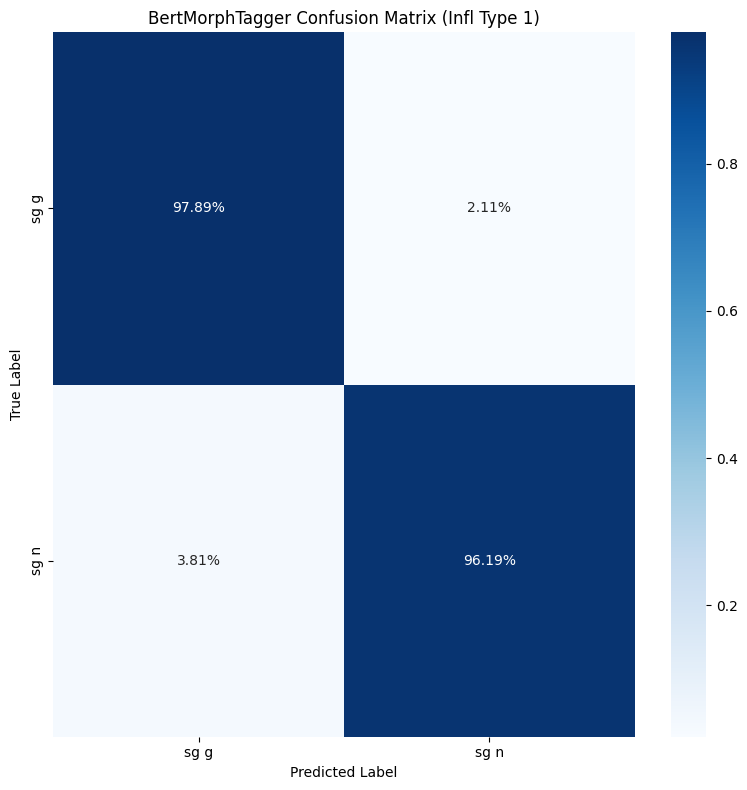

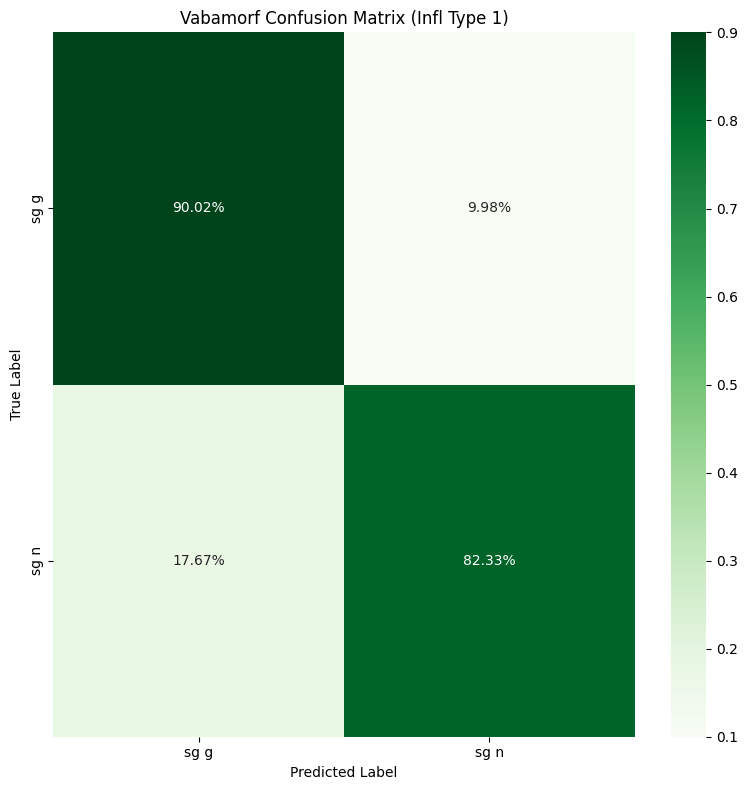

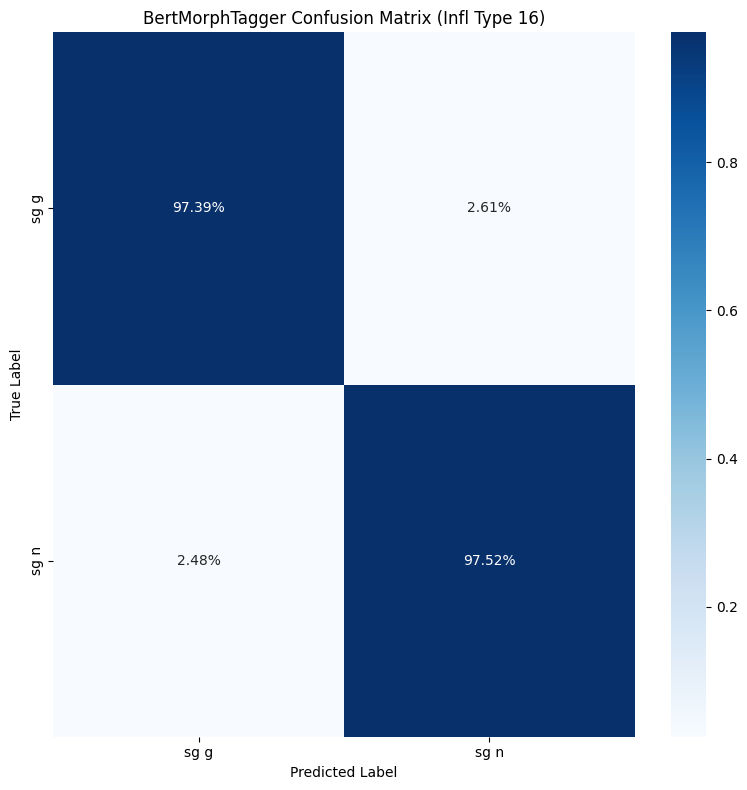

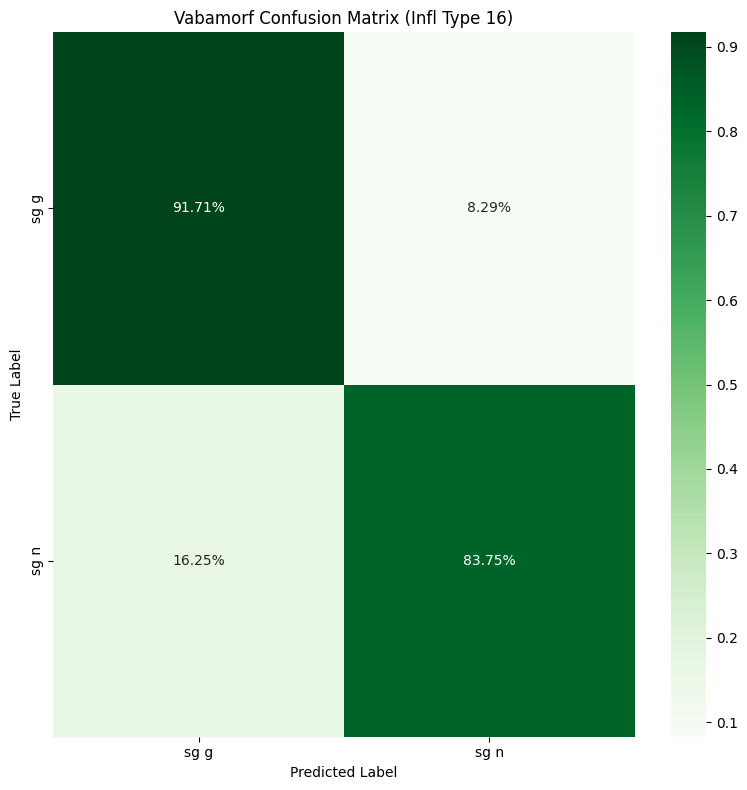

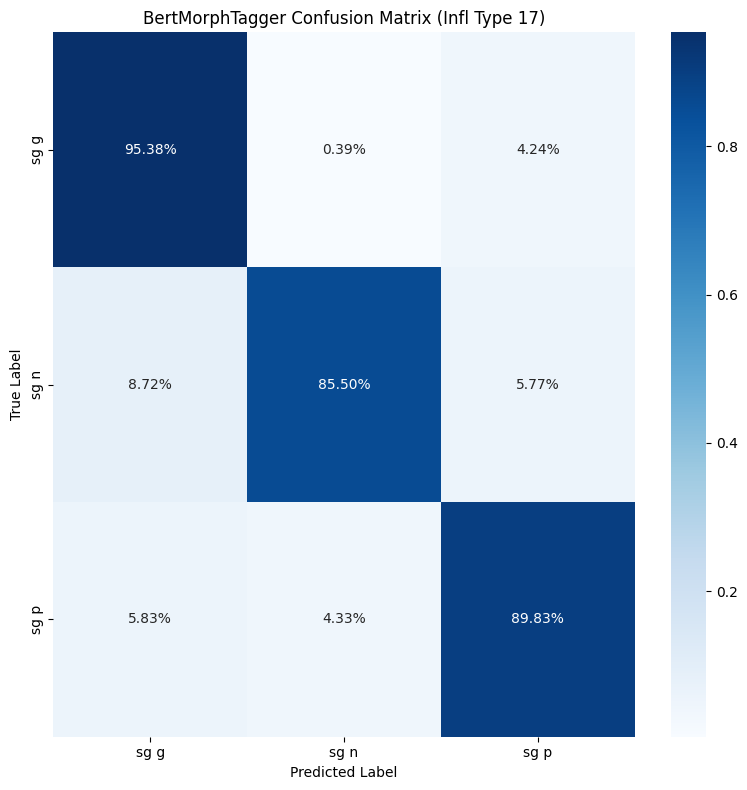

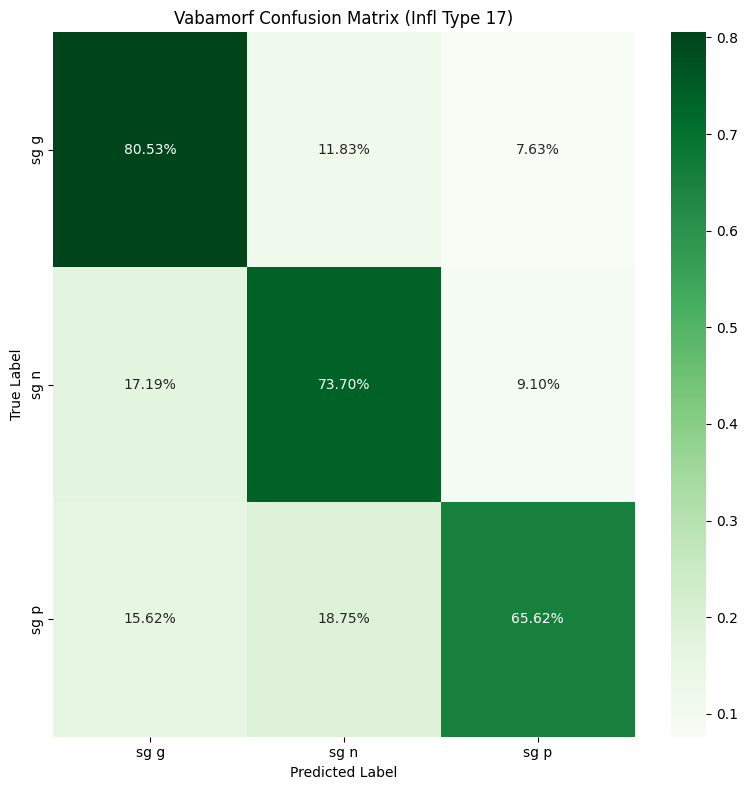

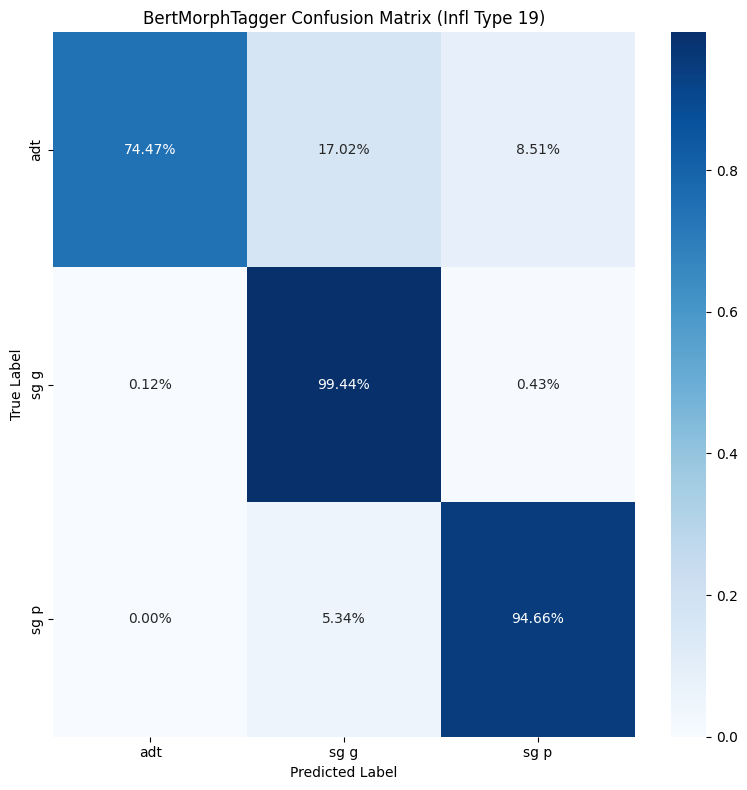

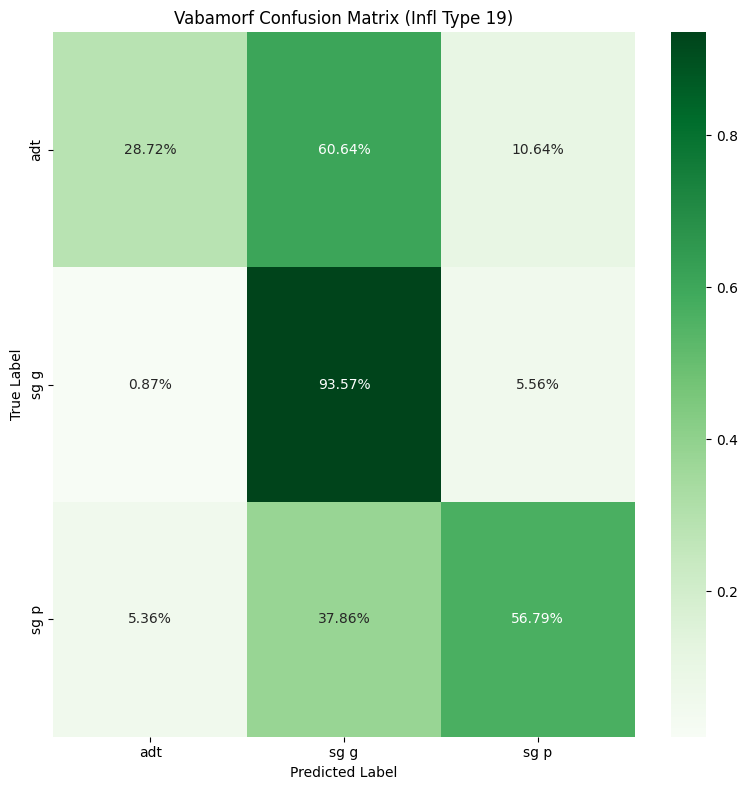

In [35]:
# Plot confusion matrices per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Filter results for the current inflection type
    results_infl = results_df[results_df["inflection_type"] == infl_type]

    # Generate confusion matrix for BertMorphTagger
    bmt_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["bmt_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    bmt_cm_infl_filtered = bmt_cm_infl[
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Generate confusion matrix for Vabamorf
    vabamorf_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["vabamorf_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    vabamorf_cm_infl_filtered = vabamorf_cm_infl[
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Plot confusion matrix for BertMorphTagger with percentage values
    plt.figure(figsize=(8, 8))
    bmt_cm_infl_normalized = (
        bmt_cm_infl_filtered.astype("float")
        / bmt_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        bmt_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"BertMorphTagger Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("../outputs/plots/v2/BertMorphTaggerCM_infl_" + str(infl_type), dpi=300)
    plt.show()

    # Plot confusion matrix for Vabamorf with percentage values
    plt.figure(figsize=(8, 8))
    vabamorf_cm_infl_normalized = (
        vabamorf_cm_infl_filtered.astype("float")
        / vabamorf_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        vabamorf_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Greens",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"Vabamorf Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("../outputs/plots/v2/VabamorfCM_infl_" + str(infl_type), dpi=300)
    plt.show()

<a id='hindamine_homonyms'></a>


### Evaluation (BertMorphTaggerHomonyms vs Vabamorf)


In [37]:
from estnltk.default_resolver import make_resolver

# Load BertMorphTagger model
bmt_model_name = "../models/NER_mudel_v2_homonym_full/"
bmt_model = BertMorphTagger(model_location=bmt_model_name)

# Load default resolver
resolver = make_resolver()

In [38]:
overall_df = pd.read_csv("../data/homonymous_word_forms/processed/homonyms_overall.csv")

In [39]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",['sg n']
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",['sg n']
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",['sg n']
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",['sg n']
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",['sg g']


In [40]:
outer = tqdm(
    overall_df.iterrows(),
    total=len(overall_df),
    desc="Evaluating BertMorphTaggerHomonym vs Vabamorf",
)


# Evaluate BertMorphTaggerHomonym vs Vabamorf
results = []
for index, row in outer:
    sentence_text = row["sentence"]
    num = row["num"]
    inflection_type = row["inflection_type"]
    word_to_analyze = row["word"]
    word_span = row["word_span"]
    true_label = row["label"][2:-2]  # Remove "['" and "']" from the label string

    # Create EstNLTK Text object
    text = estnltk.Text(sentence_text)
    text.tag_layer("sentences")

    # Apply BertMorphTagger
    bmt_model.tag(text)

    # Get BertMorphTagger prediction for the word
    # in the new bert_morph_tagging layer
    bmt_prediction = None
    for annotation in text.bert_morph_tagging:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            bmt_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(bmt_prediction, list):
                bmt_prediction = bmt_prediction[0]

    # Apply Vabamorf
    text.tag_layer(resolver=resolver)

    # Get Vabamorf prediction for the word
    vabamorf_prediction = None
    for annotation in text.morph_analysis:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            vabamorf_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(vabamorf_prediction, list):
                vabamorf_prediction = vabamorf_prediction[0]

    results.append(
        {
            "num": num,
            "inflection_type": inflection_type,
            "sentence": sentence_text,
            "word": word_to_analyze,
            "true_label": true_label,
            "bmt_prediction": bmt_prediction,
            "vabamorf_prediction": vabamorf_prediction,
        }
    )
    outer.refresh()

# Create results dataframe
results_df = pd.DataFrame(results)
results_output_csv = "../data/homonymous_word_forms/processed/homonyms_evaluation_results_v2_homonym_full.csv"
results_df.to_csv(results_output_csv, index=False)

Evaluating BertMorphTaggerHomonym vs Vabamorf:   6%|▌         | 460/7886 [00:28<08:02, 15.38it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:228: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': 'r', 'form': 'sg n', 'partofspeech': 'A', 'probability': 0.99998}]).
  warnings.warn(
Evaluating BertMorphTaggerHomonym vs Vabamorf:  35%|███▌      | 2769/7886 [02:43<06:04, 14.04it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:228: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': ',', 'form': 'sg n', 'partofspeech': 'P', 'probability': 0.44837}]).
  warnings.warn(
Evaluating BertMorphTaggerHomonym vs Vabamorf:  43%|████▎     | 3403/7886 [03:24<03:51, 19.39it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:228: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_t

<a id='tulemused_homonyms'></a>


### Results BertMorphTaggerHomonym vs Vabamorf


In [41]:
# Load results dataframe
results_df = pd.read_csv(
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results_v2_homonym_full.csv",
    index_col=False,
)

# Fill NaN predictions with "no_prediction"
results_df["bmt_prediction"] = results_df["bmt_prediction"].fillna("no_prediction")
results_df["vabamorf_prediction"] = results_df["vabamorf_prediction"].fillna(
    "no_prediction"
)

# Generate confusion matrices for both models
bmt_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["bmt_prediction"]
)

vabamorf_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["vabamorf_prediction"]
)

# Generate classification reports for both models
bmt_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["bmt_prediction"],
    zero_division=0,
)

vabamorf_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["vabamorf_prediction"],
    zero_division=0,
)

In [42]:
# Print classification reports
print("Overall Evaluation Results:")
print("BertMorphTagger Classification Report:")
print(bmt_results_cr)
print("Vabamorf Classification Report:")
print(vabamorf_results_cr)

Overall Evaluation Results:
BertMorphTagger Classification Report:
               precision    recall  f1-score   support

          adt       1.00      1.00      1.00        94
no_prediction       0.00      0.00      0.00         0
        sg el       0.00      0.00      0.00         0
         sg g       1.00      1.00      1.00      4457
         sg n       1.00      1.00      1.00      2445
         sg p       1.00      1.00      1.00       890

     accuracy                           1.00      7886
    macro avg       0.67      0.67      0.67      7886
 weighted avg       1.00      1.00      1.00      7886

Vabamorf Classification Report:
              precision    recall  f1-score   support

         adt       0.47      0.29      0.36        94
           o       0.00      0.00      0.00         0
        pl p       0.00      0.00      0.00         0
       sg es       0.00      0.00      0.00         0
        sg g       0.86      0.90      0.88      4457
        sg n       0.83

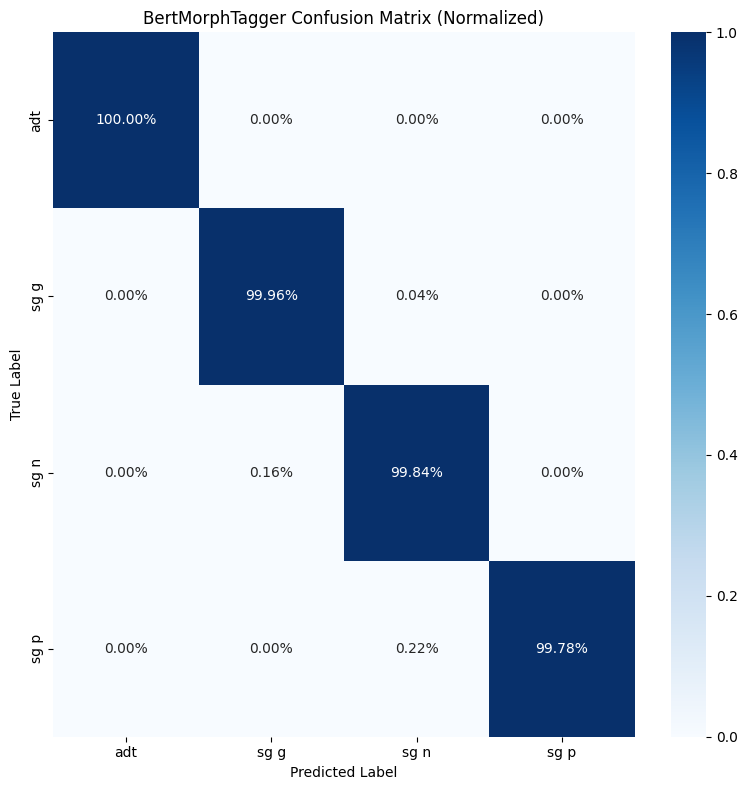

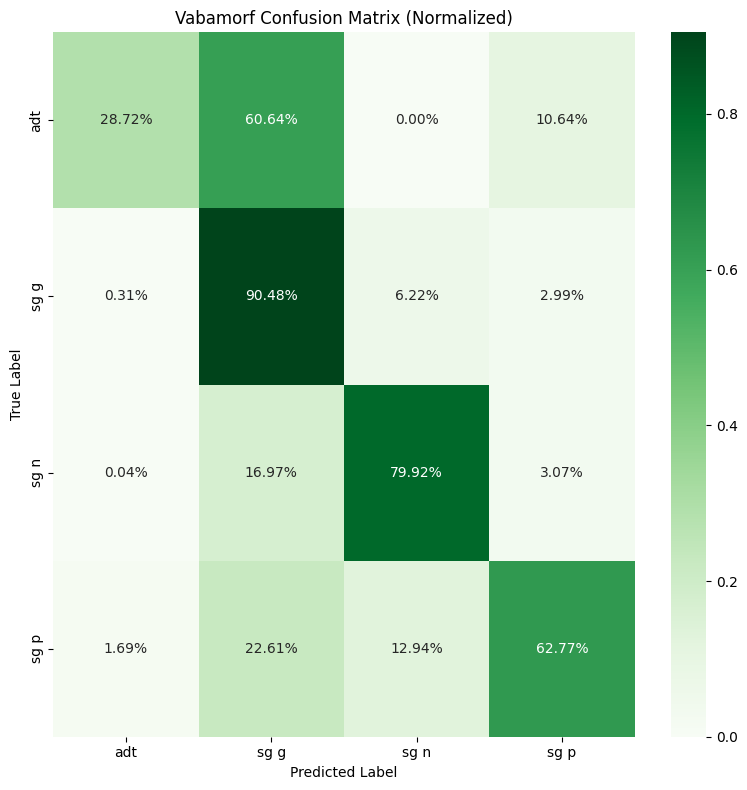

In [43]:
# Remove predictions that are not in the true labels for better visualization
bmt_cm_filtered = bmt_cm[
    np.isin(
        np.unique(results_df["bmt_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["bmt_prediction"]), np.unique(results_df["true_label"])
    ),
]

vabamorf_cm_filtered = vabamorf_cm[
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    ),
]

# Plot confusion matrix for BertMorphTagger with percentage values
plt.figure(figsize=(8, 8))
bmt_cm_normalized = (
    bmt_cm_filtered.astype("float") / bmt_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    bmt_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("BertMorphTagger Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/homonym/BertMorphTaggerCM", dpi=300)
plt.show()

# Plot confusion matrix for Vabamorf with percentage values
plt.figure(figsize=(8, 8))
vabamorf_cm_normalized = (
    vabamorf_cm_filtered.astype("float")
    / vabamorf_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    vabamorf_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("Vabamorf Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/homonym/VabamorfCM", dpi=300)
plt.show()

In [44]:
# Generate classification reports per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Generate classification report for the current inflection type
    bmt_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type]["bmt_prediction"],
        zero_division=0,
    )

    vabamorf_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type][
            "vabamorf_prediction"
        ],
        zero_division=0,
    )

    print(f"{'=' * 8}Inflection Type {infl_type}{'=' * 8}")
    print("BertMorphTagger Classification Report:")
    print(bmt_results_cr_infl)
    print("Vabamorf Classification Report:")
    print(vabamorf_results_cr_infl)

========Inflection Type 1========
BertMorphTagger Classification Report:
               precision    recall  f1-score   support

no_prediction       0.00      0.00      0.00         0
         sg g       1.00      1.00      1.00      1232
         sg n       1.00      1.00      1.00       764

     accuracy                           1.00      1996
    macro avg       0.67      0.67      0.67      1996
 weighted avg       1.00      1.00      1.00      1996

Vabamorf Classification Report:
              precision    recall  f1-score   support

        sg g       0.89      0.90      0.90      1232
        sg n       0.84      0.82      0.83       764

    accuracy                           0.87      1996
   macro avg       0.86      0.86      0.86      1996
weighted avg       0.87      0.87      0.87      1996

========Inflection Type 16========
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      10

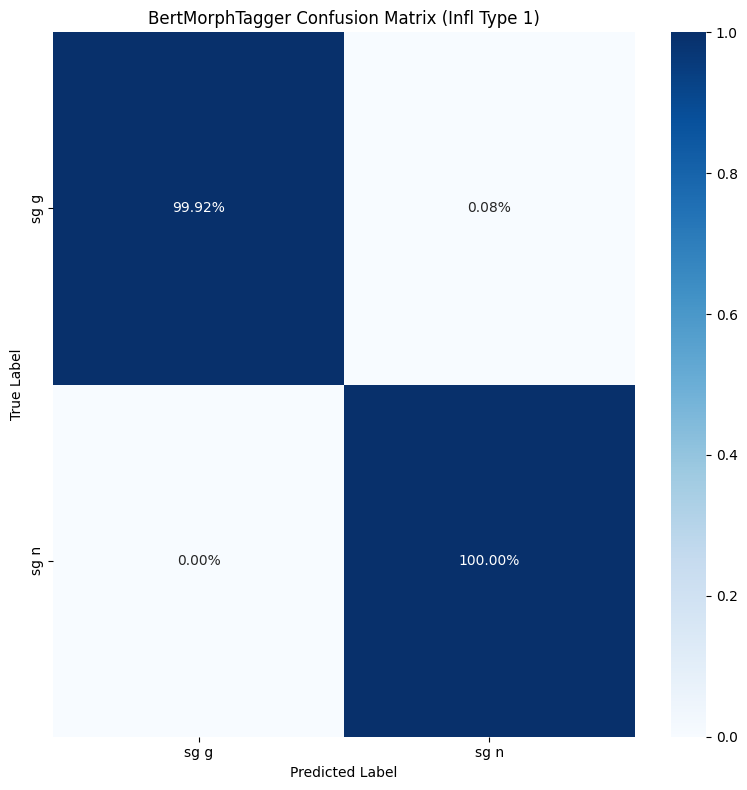

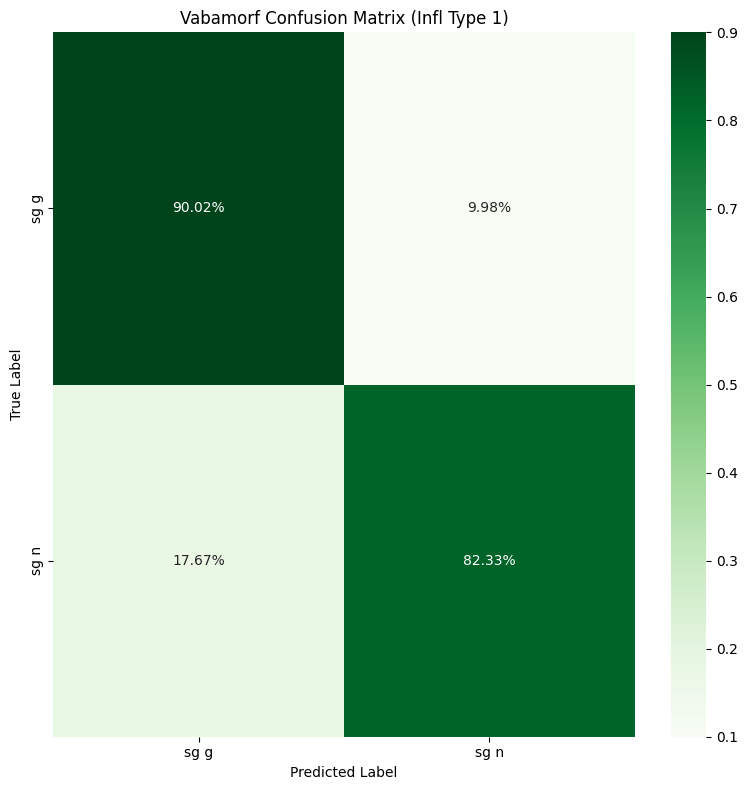

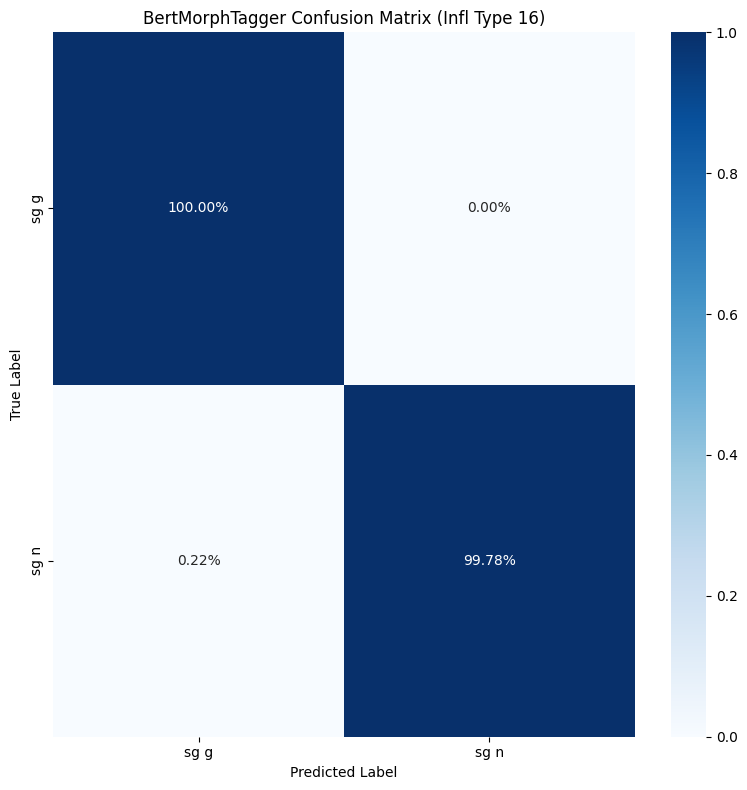

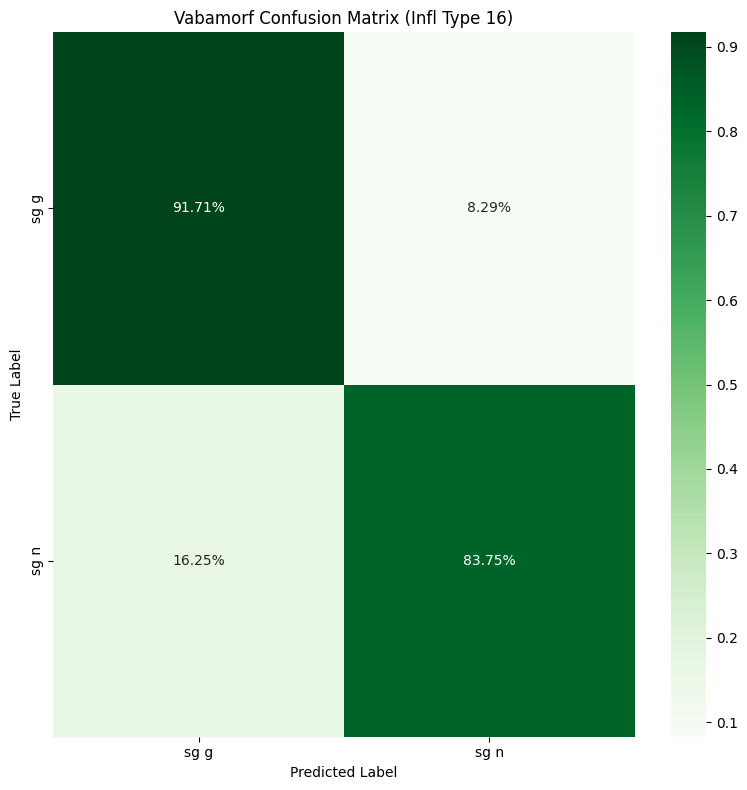

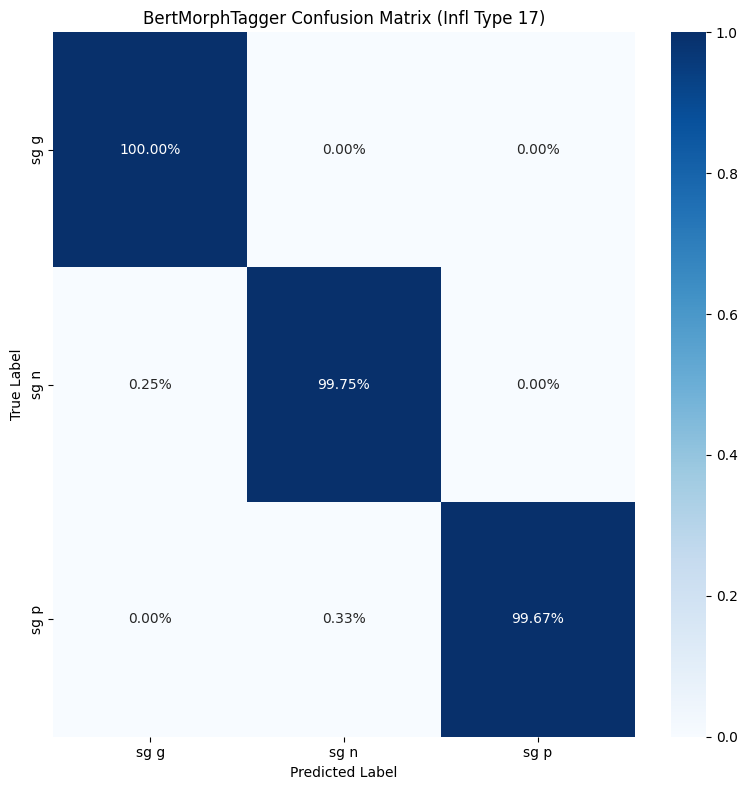

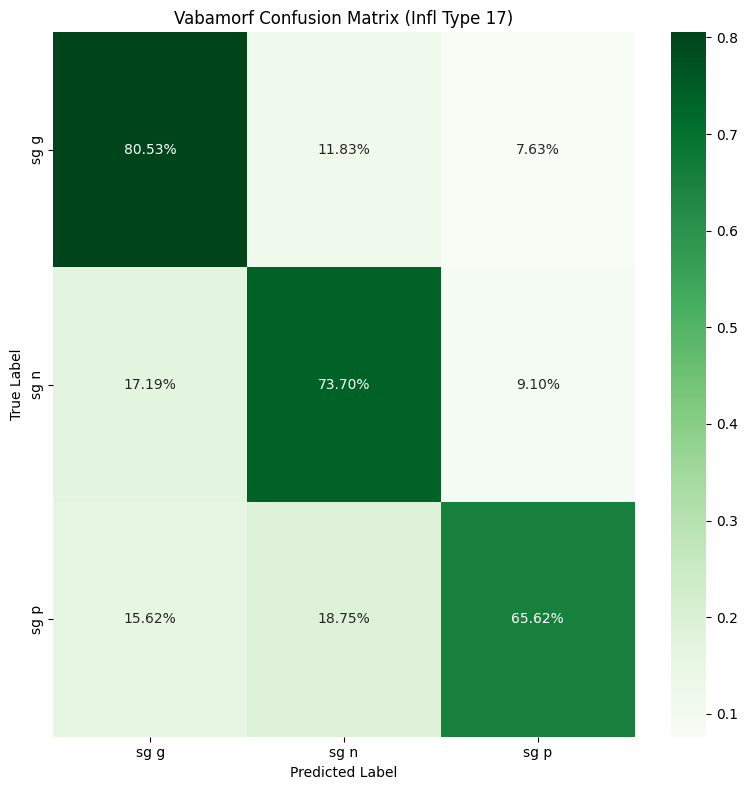

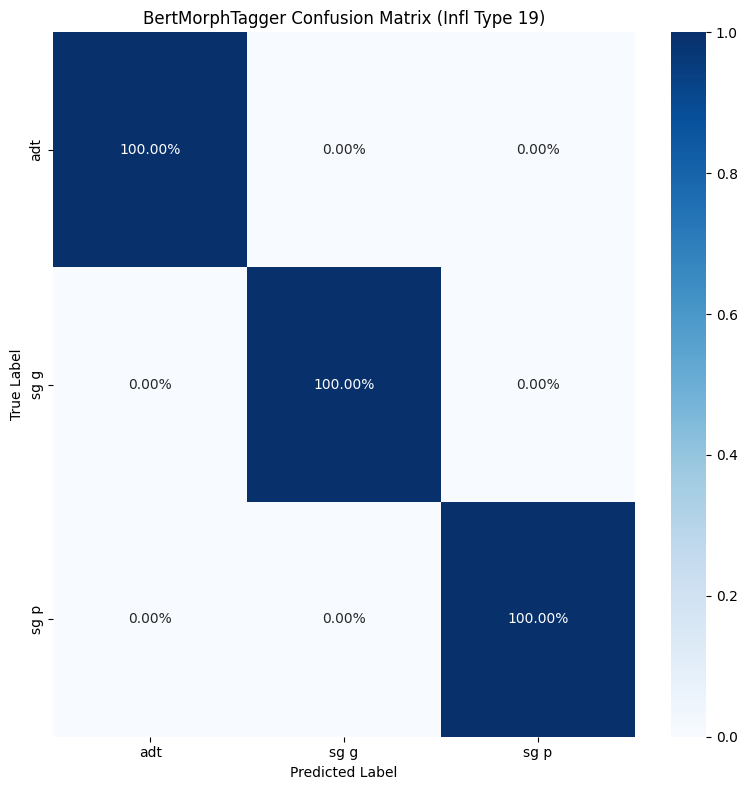

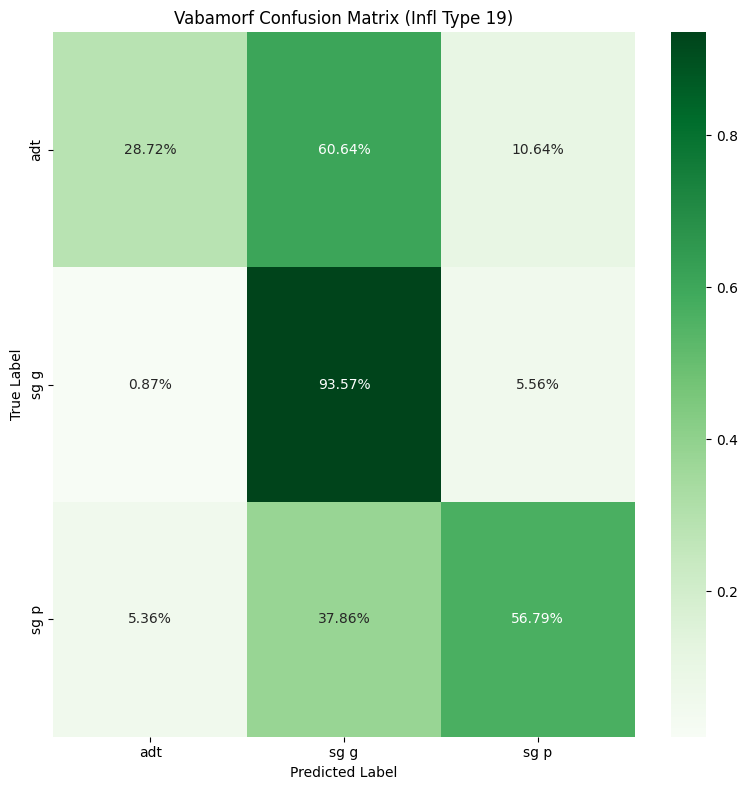

In [45]:
# Plot confusion matrices per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Filter results for the current inflection type
    results_infl = results_df[results_df["inflection_type"] == infl_type]

    # Generate confusion matrix for BertMorphTagger
    bmt_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["bmt_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    bmt_cm_infl_filtered = bmt_cm_infl[
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Generate confusion matrix for Vabamorf
    vabamorf_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["vabamorf_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    vabamorf_cm_infl_filtered = vabamorf_cm_infl[
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Plot confusion matrix for BertMorphTagger with percentage values
    plt.figure(figsize=(8, 8))
    bmt_cm_infl_normalized = (
        bmt_cm_infl_filtered.astype("float")
        / bmt_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        bmt_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"BertMorphTagger Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(
        "../outputs/plots/homonym/BertMorphTaggerCM_infl_" + str(infl_type), dpi=300
    )
    plt.show()

    # Plot confusion matrix for Vabamorf with percentage values
    plt.figure(figsize=(8, 8))
    vabamorf_cm_infl_normalized = (
        vabamorf_cm_infl_filtered.astype("float")
        / vabamorf_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        vabamorf_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Greens",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"Vabamorf Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("../outputs/plots/homonym/VabamorfCM_infl_" + str(infl_type), dpi=300)
    plt.show()

<a id='tulemused_baseline'></a>


### Baseline models (random choice and most frequent choice)


### Label distribution


In [15]:
# View label distribution in the dataset

# Count occurrences of each label in the entire dataset
label_distribution_overall = (
    results_df.groupby("true_label").size().reset_index(name="count")
)

# Calculate percentages
label_distribution_overall["percentage"] = label_distribution_overall["count"].apply(
    lambda x: round(x / label_distribution_overall["count"].sum() * 100, 3)
)
print("=" * 5, "Overall Label Distribution", "=" * 5)
print(label_distribution_overall, "\n")


# View label distribution per inflection type and add percentage columns
print("=" * 5, "Label Distribution per Inflection Type", "=" * 5)

# Count occurrences of each label per inflection type
label_distribution = (
    results_df.groupby(["inflection_type", "true_label"])
    .size()
    .reset_index(name="count")
)

# Calculate percentages
label_distribution["percentage"] = label_distribution.groupby("inflection_type")[
    "count"
].transform(lambda x: round(x / x.sum() * 100, 3))

# Separate dataframes per inflection type
label_distribution_dfs = {}
for infl_type in label_distribution["inflection_type"].unique():
    label_distribution_dfs[infl_type] = label_distribution[
        label_distribution["inflection_type"] == infl_type
    ].reset_index(drop=True)
    print(f"Inflection Type {infl_type} Label Distribution:")
    print(label_distribution_dfs[infl_type])

===== Overall Label Distribution =====
  true_label  count  percentage
0        adt     94       1.192
1       sg g   4457      56.518
2       sg n   2445      31.004
3       sg p    890      11.286 

===== Label Distribution per Inflection Type =====
Inflection Type 1 Label Distribution:
   inflection_type true_label  count  percentage
0                1       sg g   1232      61.723
1                1       sg n    764      38.277
Inflection Type 16 Label Distribution:
   inflection_type true_label  count  percentage
0               16       sg g   1080      54.822
1               16       sg n    890      45.178
Inflection Type 17 Label Distribution:
   inflection_type true_label  count  percentage
0               17       sg g    524      27.235
1               17       sg n    791      41.112
2               17       sg p    609      31.653
Inflection Type 19 Label Distribution:
   inflection_type true_label  count  percentage
0               19        adt     94       4.709
1    

#### Overall homonym dataset


In [15]:
seed = 42069360
# Create a most frequent class baseline
most_frequent_baseline = sklearn.dummy.DummyClassifier(
    strategy="most_frequent", random_state=seed
)
# Create a random choice baseline
random_choice_baseline = sklearn.dummy.DummyClassifier(
    strategy="uniform", random_state=seed
)

In [16]:
# Fit and evaluate baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    baseline.fit(
        results_df["true_label"],
        results_df["true_label"],
    )
    baseline_predictions = baseline.predict(
        results_df["true_label"],
    )
    baseline_cr = sklearn.metrics.classification_report(
        y_true=results_df["true_label"],
        y_pred=baseline_predictions,
        zero_division=0,
    )
    print(f"{name} Classification Report:")
    print(baseline_cr)

Most Frequent Class Baseline Classification Report:
              precision    recall  f1-score   support

         adt       0.00      0.00      0.00        94
        sg g       0.57      1.00      0.72      4457
        sg n       0.00      0.00      0.00      2445
        sg p       0.00      0.00      0.00       890

    accuracy                           0.57      7886
   macro avg       0.14      0.25      0.18      7886
weighted avg       0.32      0.57      0.41      7886

Random Choice Baseline Classification Report:
              precision    recall  f1-score   support

         adt       0.01      0.27      0.02        94
        sg g       0.55      0.25      0.34      4457
        sg n       0.31      0.25      0.28      2445
        sg p       0.11      0.25      0.16       890

    accuracy                           0.25      7886
   macro avg       0.25      0.25      0.20      7886
weighted avg       0.42      0.25      0.30      7886



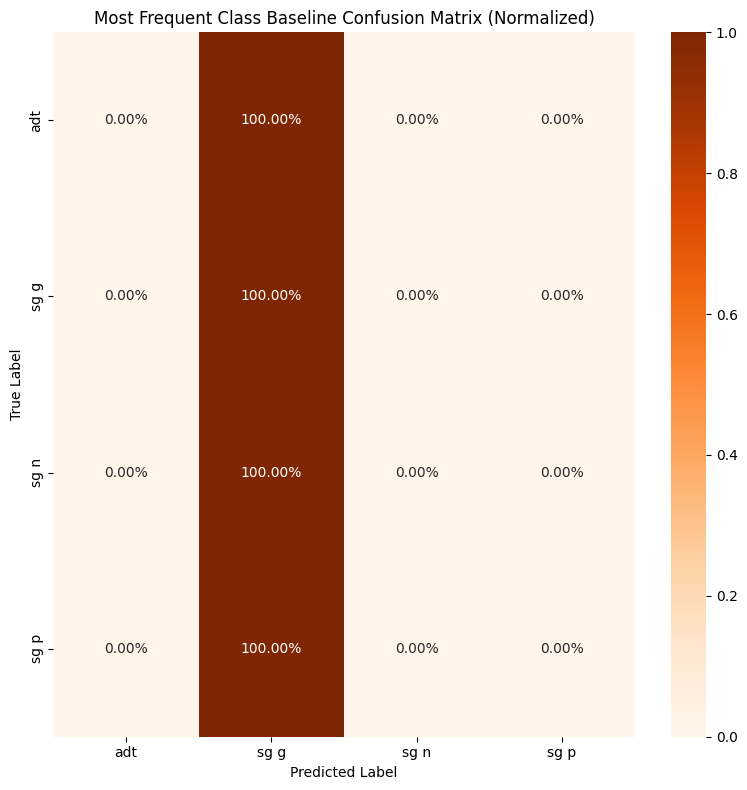

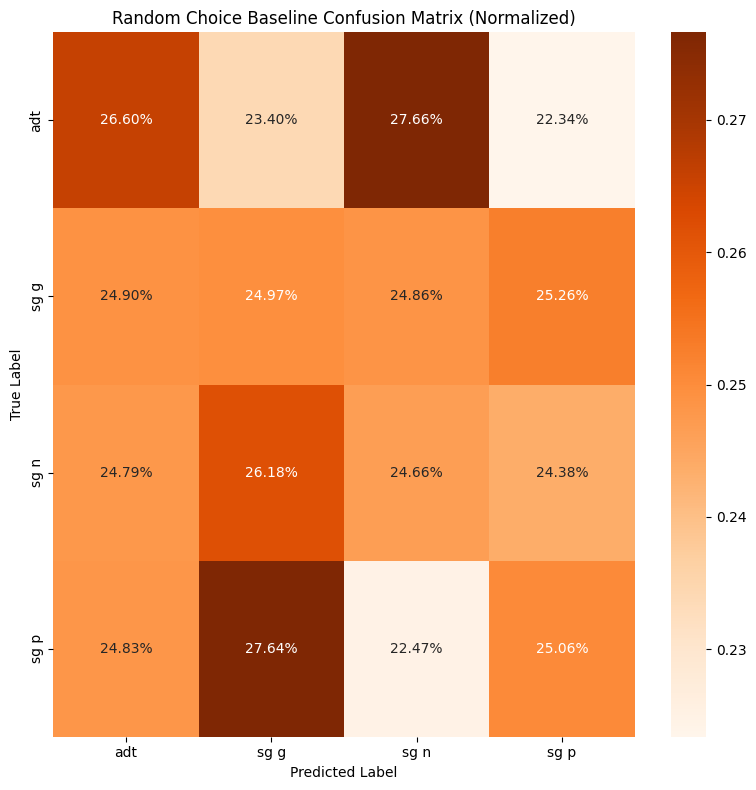

In [19]:
# Plot confusion matrices for overall results with baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    baseline_predictions = baseline.predict(
        results_df["true_label"],
    )
    baseline_cm = sklearn.metrics.confusion_matrix(
        y_true=results_df["true_label"], y_pred=baseline_predictions
    )
    baseline_cm_normalized = (
        baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]
    )
    plt.figure(figsize=(8, 8))
    sns.heatmap(
        baseline_cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Oranges",
        xticklabels=np.unique(results_df["true_label"]),
        yticklabels=np.unique(results_df["true_label"]),
    )
    plt.title(f"{name} Confusion Matrix (Normalized)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(
        "../outputs/plots/baseline/homonym_ds/" + name.replace(" ", "") + "CM", dpi=300
    )
    plt.show()

#### Per inflection type homonym dataset


In [20]:
seed = 42069360
# Create a most frequent class baseline
most_frequent_baseline = sklearn.dummy.DummyClassifier(
    strategy="most_frequent", random_state=seed
)
# Create a random choice baseline
random_choice_baseline = sklearn.dummy.DummyClassifier(
    strategy="uniform", random_state=seed
)

In [21]:
# Fit and evaluate baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    for inflection_type in results_df["inflection_type"].unique():
        baseline.fit(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_predictions = baseline.predict(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_cr = sklearn.metrics.classification_report(
            y_true=results_df[results_df["inflection_type"] == inflection_type][
                "true_label"
            ],
            y_pred=baseline_predictions,
            zero_division=0,
        )
        print(f"{name} Classification Report for Inflection Type {inflection_type}:")
        print(baseline_cr)

Most Frequent Class Baseline Classification Report for Inflection Type 1:
              precision    recall  f1-score   support

        sg g       0.62      1.00      0.76      1232
        sg n       0.00      0.00      0.00       764

    accuracy                           0.62      1996
   macro avg       0.31      0.50      0.38      1996
weighted avg       0.38      0.62      0.47      1996

Most Frequent Class Baseline Classification Report for Inflection Type 16:
              precision    recall  f1-score   support

        sg g       0.55      1.00      0.71      1080
        sg n       0.00      0.00      0.00       890

    accuracy                           0.55      1970
   macro avg       0.27      0.50      0.35      1970
weighted avg       0.30      0.55      0.39      1970

Most Frequent Class Baseline Classification Report for Inflection Type 17:
              precision    recall  f1-score   support

        sg g       0.00      0.00      0.00       524
        sg n 

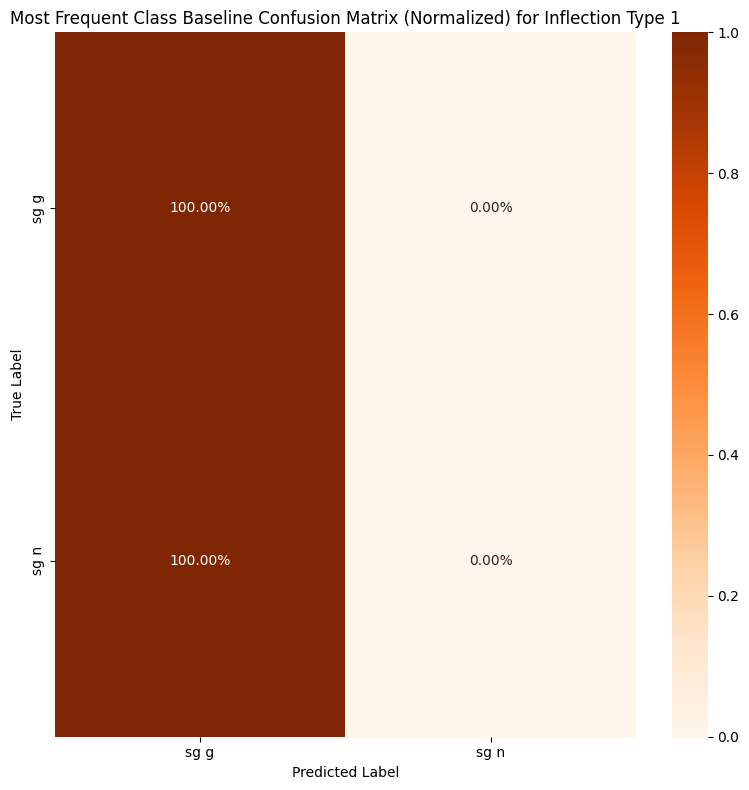

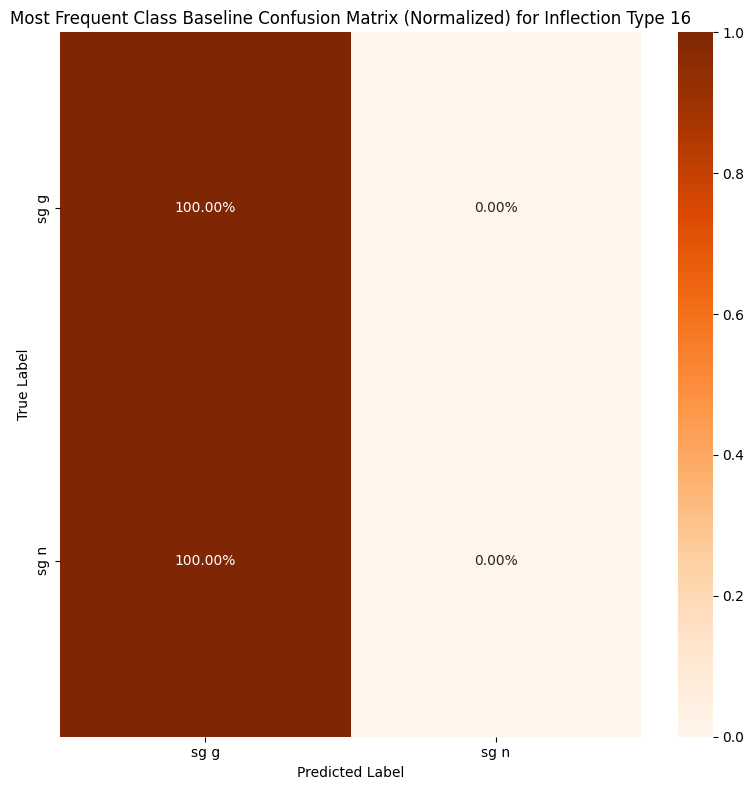

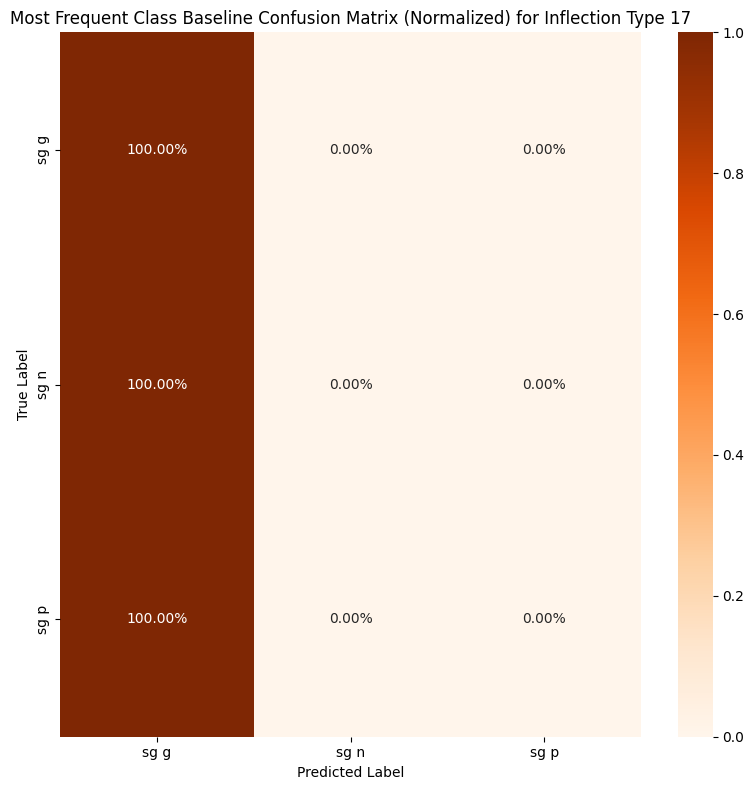

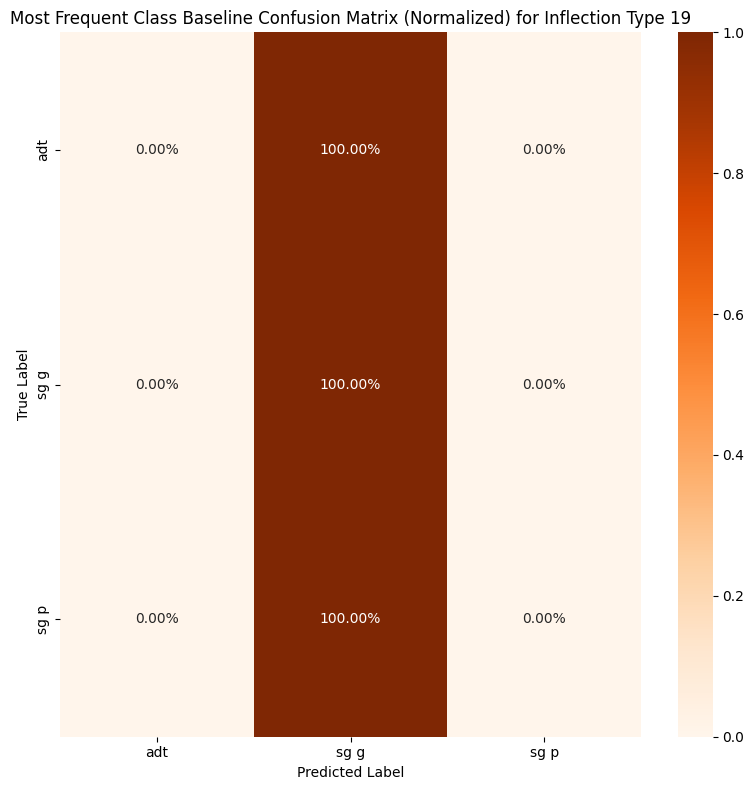

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


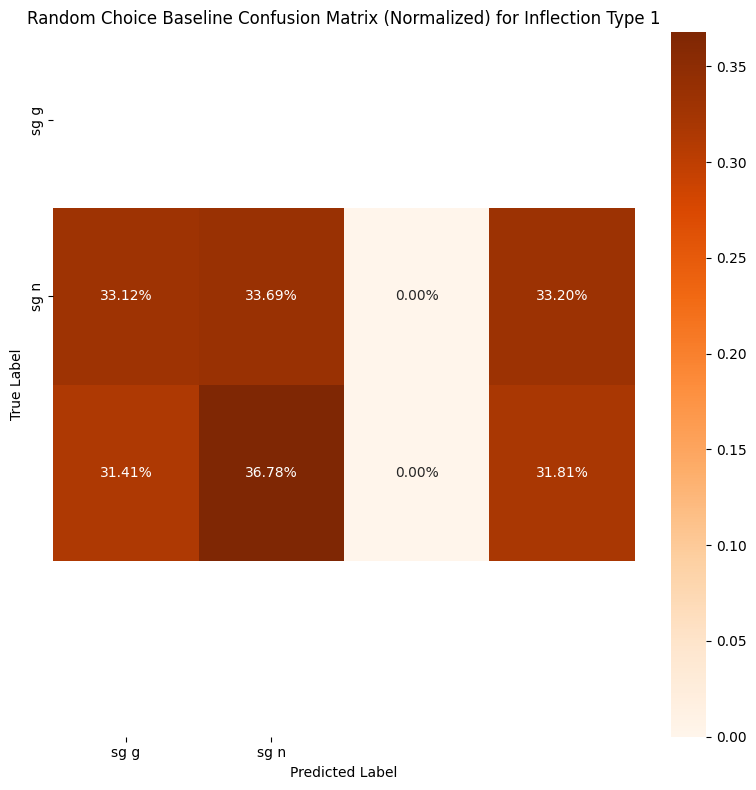

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


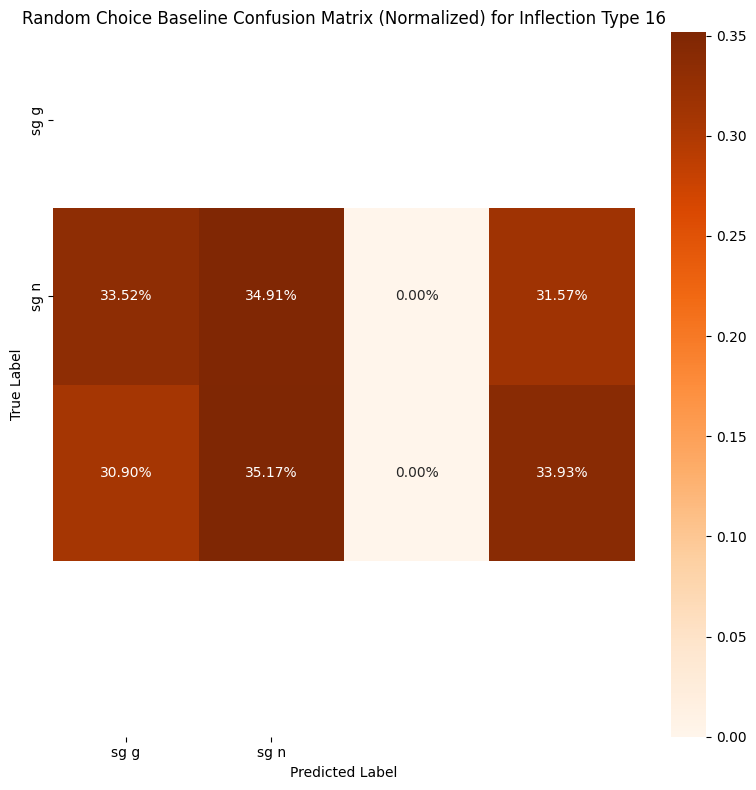

C:\Users\Admin\AppData\Local\Temp\ipykernel_31356\1038238969.py:17: RuntimeWarning: invalid value encountered in divide
  baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]


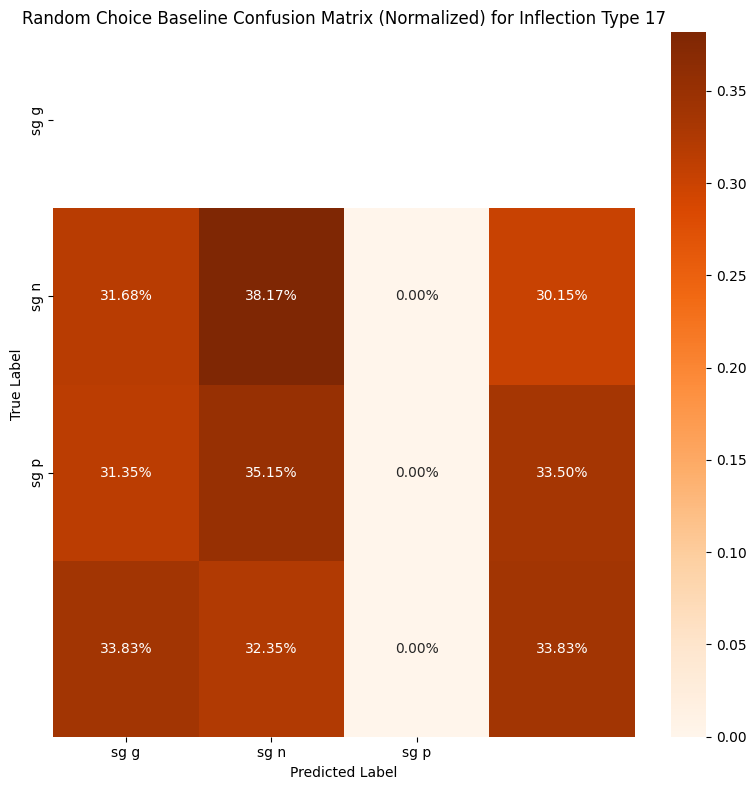

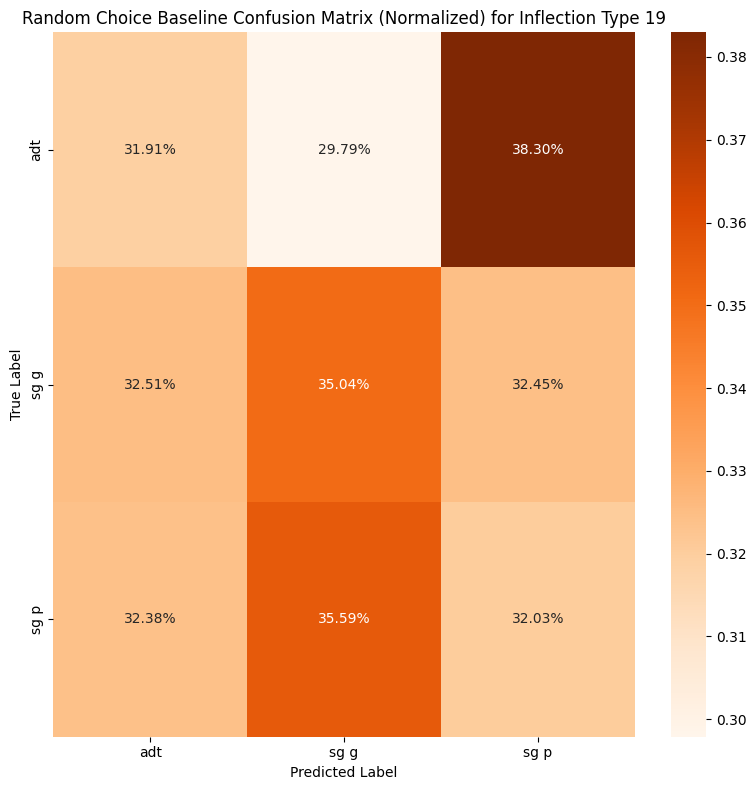

In [23]:
# Plot confusion matrices per inflection type for baselines
for baseline, name in [
    (most_frequent_baseline, "Most Frequent Class Baseline"),
    (random_choice_baseline, "Random Choice Baseline"),
]:
    for inflection_type in results_df["inflection_type"].unique():
        baseline_predictions = baseline.predict(
            results_df[results_df["inflection_type"] == inflection_type]["true_label"],
        )
        baseline_cm = sklearn.metrics.confusion_matrix(
            y_true=results_df[results_df["inflection_type"] == inflection_type][
                "true_label"
            ],
            y_pred=baseline_predictions,
        )
        baseline_cm_normalized = (
            baseline_cm.astype("float") / baseline_cm.sum(axis=1)[:, np.newaxis]
        )
        plt.figure(figsize=(8, 8))
        sns.heatmap(
            baseline_cm_normalized,
            annot=True,
            fmt=".2%",
            cmap="Oranges",
            xticklabels=np.unique(
                results_df[results_df["inflection_type"] == inflection_type][
                    "true_label"
                ]
            ),
            yticklabels=np.unique(
                results_df[results_df["inflection_type"] == inflection_type][
                    "true_label"
                ]
            ),
        )
        plt.title(
            f"{name} Confusion Matrix (Normalized) for Inflection Type {inflection_type}"
        )
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.savefig(
            "../outputs/plots/baseline/homonym_ds/"
            + name.replace(" ", "")
            + "CM_"
            + "infl_"
            + str(inflection_type),
            dpi=300,
        )
        plt.show()

### Evaluation (BertMorphTaggerHomonyms_small vs Vabamorf)


In [4]:
from estnltk.default_resolver import make_resolver

# Load BertMorphTagger model
bmt_model_name = "../models/NER_mudel_v2_homonym_50/"
bmt_model = BertMorphTagger(model_location=bmt_model_name)

# Load default resolver
resolver = make_resolver()

In [ ]:
overall_df = pd.read_csv("../data/homonymous_word_forms/processed/homonyms_overall.csv")
test_df = pd.read_csv("../data/homonymous_word_forms/processed/homonyms_model_test.csv")

In [10]:
display(overall_df.head())
display(test_df.head())

,num,inflection_type,sentence,word,word_span,label
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",['sg n']
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"(20, 27)",['sg n']
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"(51, 60)",['sg n']
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"(16, 20)",['sg n']
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"(0, 7)",['sg g']


,sentence_id,words,labels
0,0,Edinburghi,-
1,0,agulite,-
2,0,mehe,-
3,0,Irvine,-
4,0,Welshi,-


In [14]:
# Gather sentences from the overall dataset with the sentence_ids in the test set
# Use index of the overall_df as sentence_id
test_sentence_ids = test_df["sentence_id"].tolist()
test_sentences = overall_df[overall_df.index.isin(test_sentence_ids)][
    ["num", "sentence", "word", "word_span", "label", "inflection_type"]
].reset_index(drop=True)
display(test_sentences.head())

,num,sentence,word,word_span,label,inflection_type
0,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"(74, 80)",['sg n'],1
1,1,"Siiditee John W. Orrison, endine CSX Transportationi presidendi abi, on rääkinud Wall Street Journalile, et kaupade eksportimine Hiinast ja Koreast Euroopa Liitu on piiramatu potentsiaaliga äri, kus liigub aastas kümneid miljardeid eurosid.",piiramatu,"(165, 174)",['sg g'],1
2,1,"""Mängijad peavad tegutsema maksimaalselt sihikindlalt, ainult siis võime võitlusele häälestunud tartlasi ületada,"" rääkis võitjate juhendaja Maarten van Gent.",juhendaja,"(131, 140)",['sg n'],1
3,1,"Ehitustööriista abitreeneri Heino Rebase jaoks oli eile kaela saadud kuldmedal väga erilise tähendusega üheksakümnendate esimesel poolel oli ta ihaldatud trofeed Baltika peatreenerina nii kaua püüdnud, kuni peasponsor üritamisest loobus ja klubi laiali läks.",Baltika,"(162, 169)",['sg g'],1
4,1,"Põhja-Koreaga alustas Jaapan läbirääkimisi 1992. aastal, kuid need katkesid aasta hiljem just samal põhjusel, mille üle nüüdki vaieldakse.",aasta,"(76, 81)",['sg n'],1


In [ ]:
outer = tqdm(
    test_sentences.iterrows(),
    total=len(test_sentences),
    desc="Evaluating BertMorphTaggerHomonym vs Vabamorf",
)


# Evaluate BertMorphTaggerHomonym vs Vabamorf
results = []
for index, row in outer:
    sentence_text = row["sentence"]
    num = row["num"]
    inflection_type = row["inflection_type"]
    word_to_analyze = row["word"]
    word_span = row["word_span"]
    true_label = row["label"][2:-2]  # Remove "['" and "']" from the label string

    # Create EstNLTK Text object
    text = estnltk.Text(sentence_text)
    text.tag_layer("sentences")

    # Apply BertMorphTagger
    bmt_model.tag(text)

    # Get BertMorphTagger prediction for the word
    # in the new bert_morph_tagging layer
    bmt_prediction = None
    for annotation in text.bert_morph_tagging:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            bmt_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(bmt_prediction, list):
                bmt_prediction = bmt_prediction[0]

    # Apply Vabamorf
    text.tag_layer(resolver=resolver)

    # Get Vabamorf prediction for the word
    vabamorf_prediction = None
    for annotation in text.morph_analysis:
        annotation_word_span = str((annotation.start, annotation.end))
        if annotation_word_span == word_span:
            vabamorf_prediction = annotation.form[0]  # Get the first analysis
            # If the form is still a list, take the first element
            if isinstance(vabamorf_prediction, list):
                vabamorf_prediction = vabamorf_prediction[0]

    results.append(
        {
            "num": num,
            "inflection_type": inflection_type,
            "sentence": sentence_text,
            "word": word_to_analyze,
            "true_label": true_label,
            "bmt_prediction": bmt_prediction,
            "vabamorf_prediction": vabamorf_prediction,
        }
    )
    outer.refresh()

# Create results dataframe
results_df = pd.DataFrame(results)
results_output_csv = "../data/homonymous_word_forms/processed/homonyms_evaluation_results_v2_homonym_50.csv"
results_df.to_csv(results_output_csv, index=False)

Evaluating BertMorphTaggerHomonym vs Vabamorf:  20%|█▉        | 388/1972 [00:34<02:01, 13.07it/s]E:\Git_projects/EstNLTK/EstNLTK_model_training\scripts\model\bert_tokens_to_words_rewriter.py:183: UserWarning: (!) No matching words span for bert token Span(' ', [{'bert_tokens': '▁', 'form': 'sg n', 'partofspeech': 'S', 'probability': 0.99993}]).
  warnings.warn(
Evaluating BertMorphTaggerHomonym vs Vabamorf: 100%|██████████| 1972/1972 [02:41<00:00, 12.23it/s]


<a id='tulemused_homonyms'></a>


### Results BertMorphTaggerHomonym vs Vabamorf


In [ ]:
# Load results dataframe
results_df = pd.read_csv(
    "../data/homonymous_word_forms/processed/homonyms_evaluation_results_v2_homonym_50.csv",
    index_col=False,
)

# Fill NaN predictions with "no_prediction"
results_df["bmt_prediction"] = results_df["bmt_prediction"].fillna("no_prediction")
results_df["vabamorf_prediction"] = results_df["vabamorf_prediction"].fillna(
    "no_prediction"
)

# Generate confusion matrices for both models
bmt_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["bmt_prediction"]
)

vabamorf_cm = sklearn.metrics.confusion_matrix(
    y_true=results_df["true_label"], y_pred=results_df["vabamorf_prediction"]
)

# Generate classification reports for both models
bmt_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["bmt_prediction"],
    zero_division=0,
)

vabamorf_results_cr = sklearn.metrics.classification_report(
    y_true=results_df["true_label"],
    y_pred=results_df["vabamorf_prediction"],
    zero_division=0,
)

In [17]:
# Print classification reports
print("Overall Evaluation Results:")
print("BertMorphTagger Classification Report:")
print(bmt_results_cr)
print("Vabamorf Classification Report:")
print(vabamorf_results_cr)

Overall Evaluation Results:
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

         adt       1.00      1.00      1.00        23
        sg g       1.00      1.00      1.00      1108
        sg n       1.00      1.00      1.00       635
        sg p       1.00      1.00      1.00       206

    accuracy                           1.00      1972
   macro avg       1.00      1.00      1.00      1972
weighted avg       1.00      1.00      1.00      1972

Vabamorf Classification Report:
              precision    recall  f1-score   support

         adt       0.67      0.35      0.46        23
        sg g       0.86      0.90      0.88      1108
        sg n       0.83      0.82      0.83       635
        sg p       0.72      0.61      0.66       206

    accuracy                           0.84      1972
   macro avg       0.77      0.67      0.71      1972
weighted avg       0.84      0.84      0.84      1972



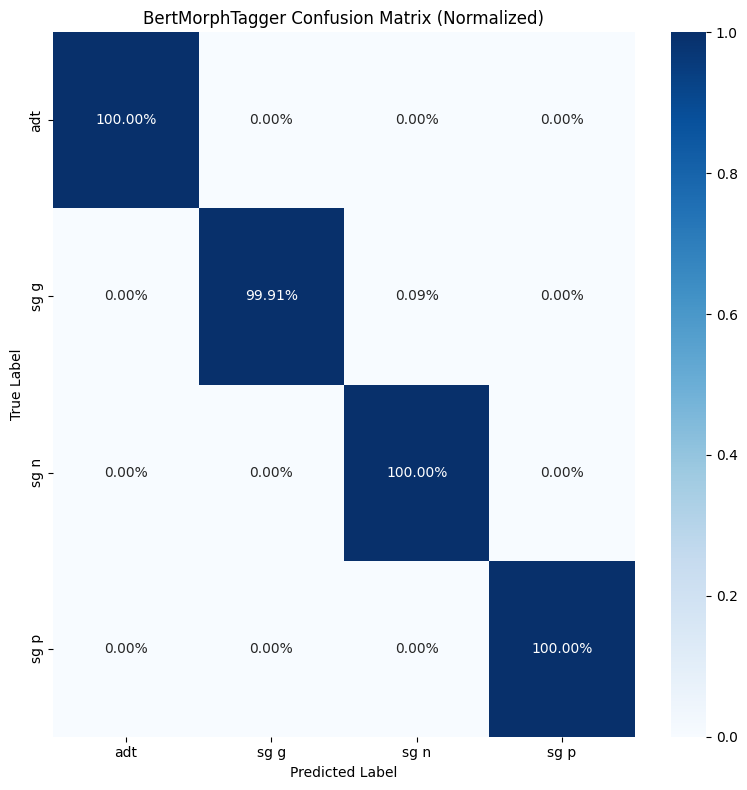

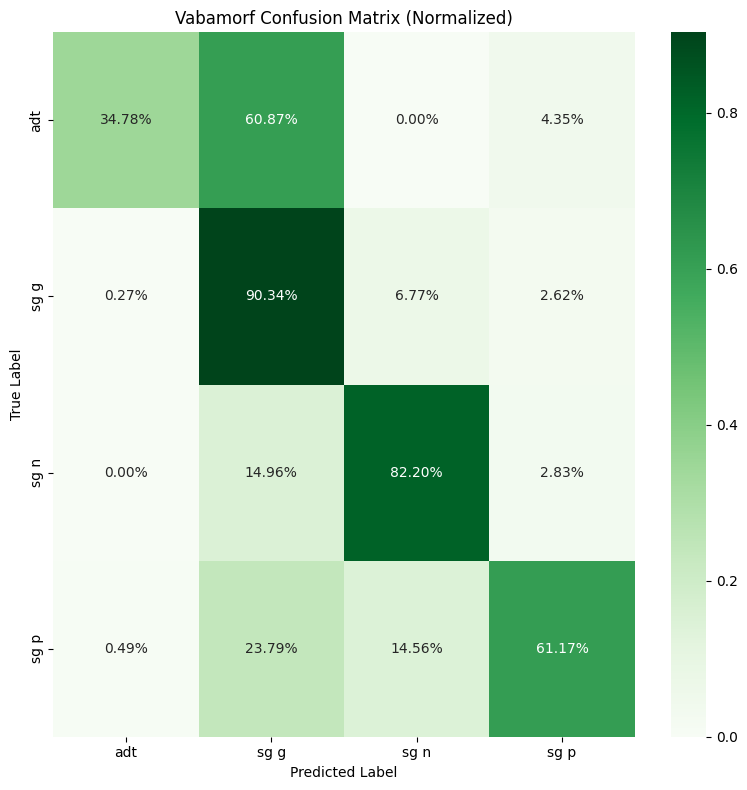

In [20]:
# Remove predictions that are not in the true labels for better visualization
bmt_cm_filtered = bmt_cm[
    np.isin(
        np.unique(results_df["bmt_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["bmt_prediction"]), np.unique(results_df["true_label"])
    ),
]

vabamorf_cm_filtered = vabamorf_cm[
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    )
][
    :,
    np.isin(
        np.unique(results_df["vabamorf_prediction"]),
        np.unique(results_df["true_label"]),
    ),
]

# Plot confusion matrix for BertMorphTagger with percentage values
plt.figure(figsize=(8, 8))
bmt_cm_normalized = (
    bmt_cm_filtered.astype("float") / bmt_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    bmt_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("BertMorphTagger Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/homonym_small/BertMorphTaggerCM", dpi=300)
plt.show()

# Plot confusion matrix for Vabamorf with percentage values
plt.figure(figsize=(8, 8))
vabamorf_cm_normalized = (
    vabamorf_cm_filtered.astype("float")
    / vabamorf_cm_filtered.sum(axis=1)[:, np.newaxis]
)
sns.heatmap(
    vabamorf_cm_normalized,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=np.unique(results_df["true_label"]),
    yticklabels=np.unique(results_df["true_label"]),
)
plt.title("Vabamorf Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../outputs/plots/homonym_small/VabamorfCM", dpi=300)
plt.show()

In [ ]:
# Generate classification reports per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Generate classification report for the current inflection type
    bmt_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type]["bmt_prediction"],
        zero_division=0,
    )

    vabamorf_results_cr_infl = sklearn.metrics.classification_report(
        y_true=results_df[results_df["inflection_type"] == infl_type]["true_label"],
        y_pred=results_df[results_df["inflection_type"] == infl_type][
            "vabamorf_prediction"
        ],
        zero_division=0,
    )

    print(f"{'=' * 8}Inflection Type {infl_type}{'=' * 8}")
    print("BertMorphTagger Classification Report:")
    print(bmt_results_cr_infl)
    print("Vabamorf Classification Report:")
    print(vabamorf_results_cr_infl)

========Inflection Type 1========
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1232
        sg n       1.00      1.00      1.00       764
        sg p       0.00      0.00      0.00         0

    accuracy                           1.00      1996
   macro avg       0.67      0.67      0.67      1996
weighted avg       1.00      1.00      1.00      1996

Vabamorf Classification Report:
              precision    recall  f1-score   support

        sg g       0.89      0.90      0.90      1232
        sg n       0.84      0.82      0.83       764

    accuracy                           0.87      1996
   macro avg       0.86      0.86      0.86      1996
weighted avg       0.87      0.87      0.87      1996

========Inflection Type 16========
BertMorphTagger Classification Report:
              precision    recall  f1-score   support

        sg g       1.00      1.00      1.00      1080
    

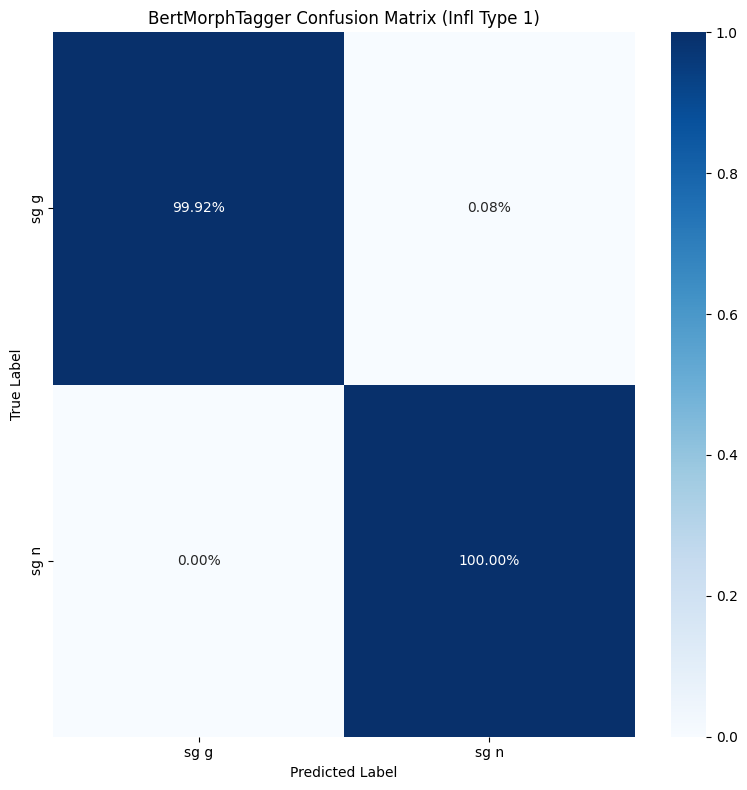

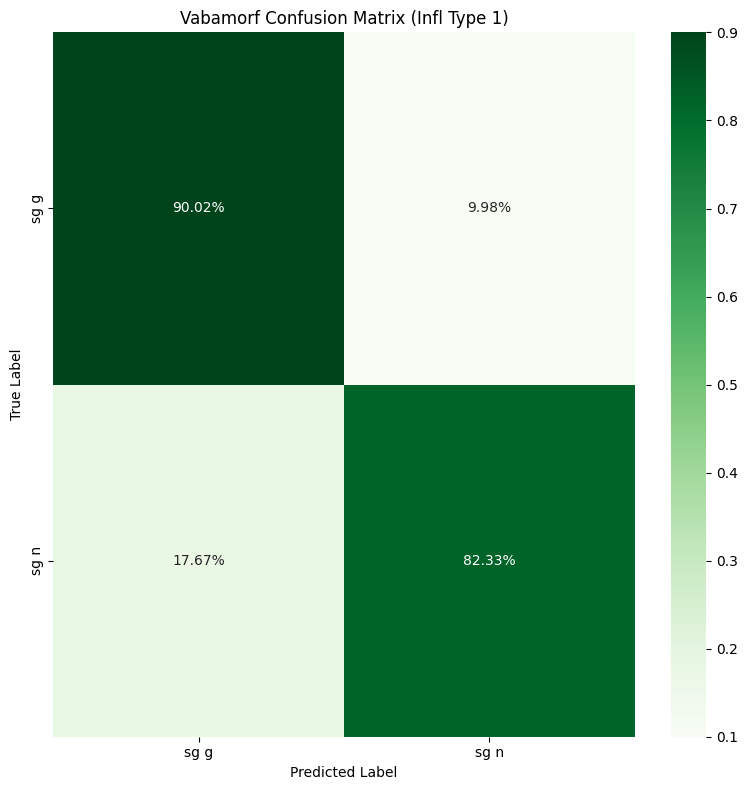

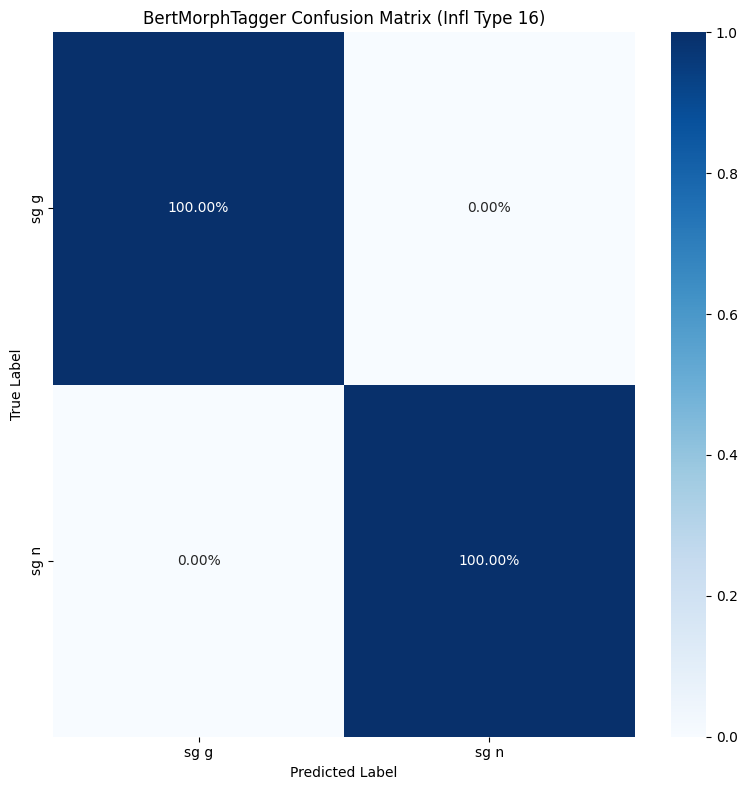

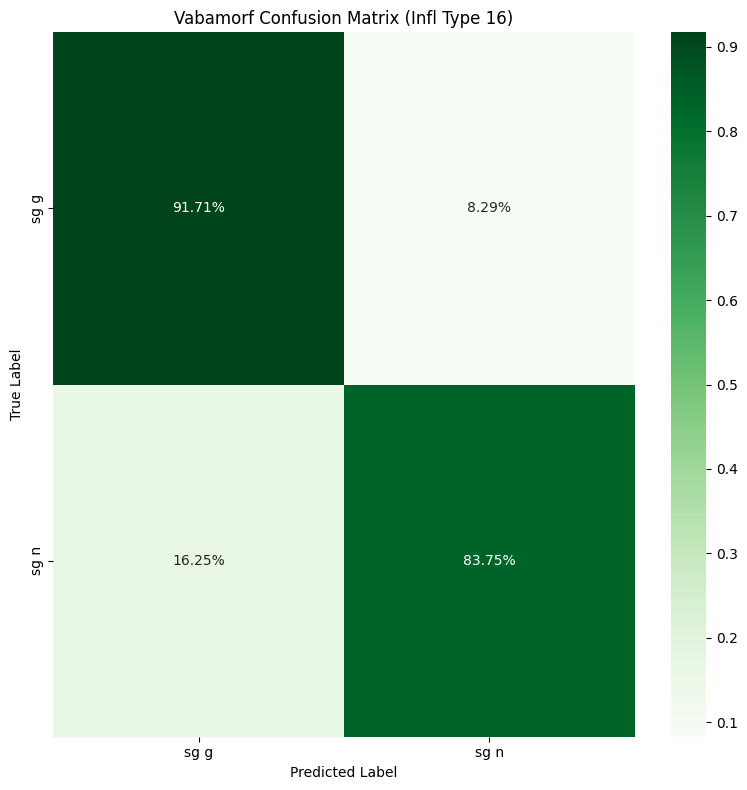

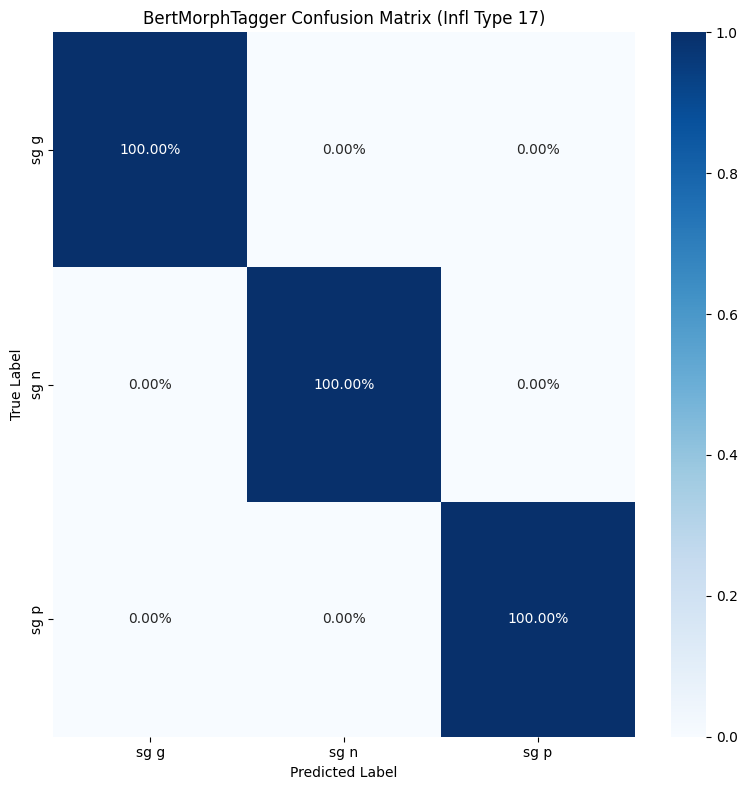

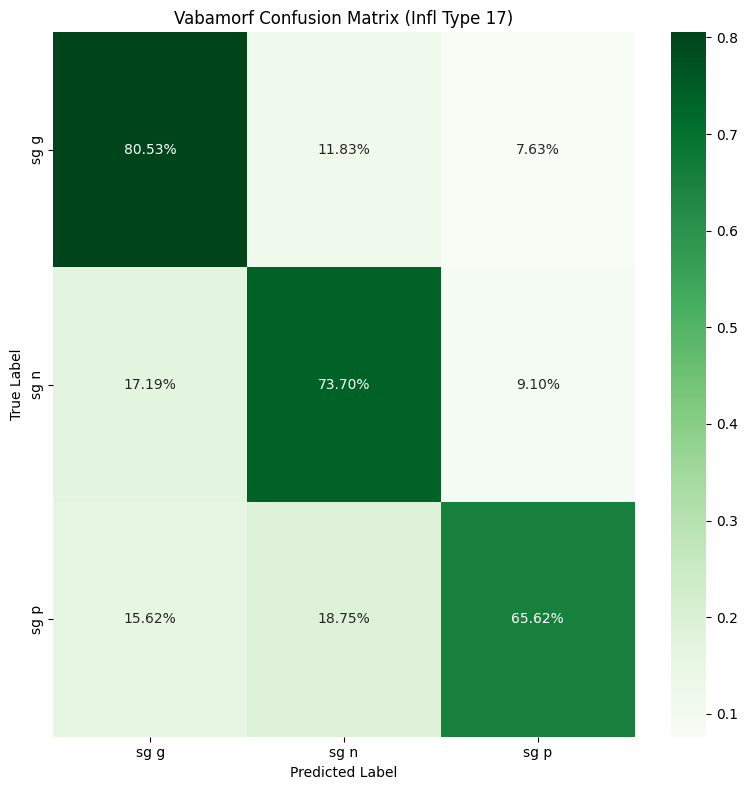

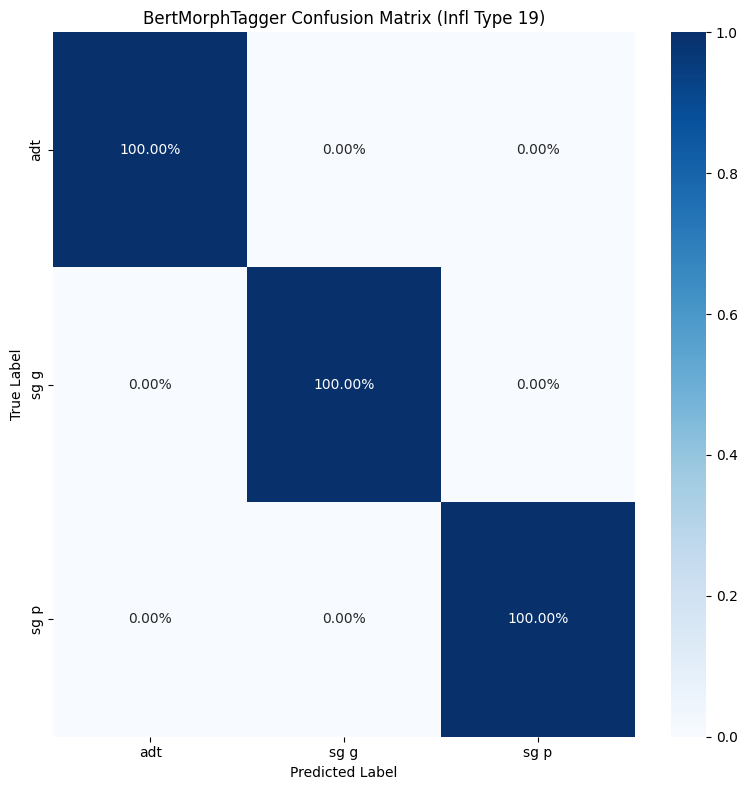

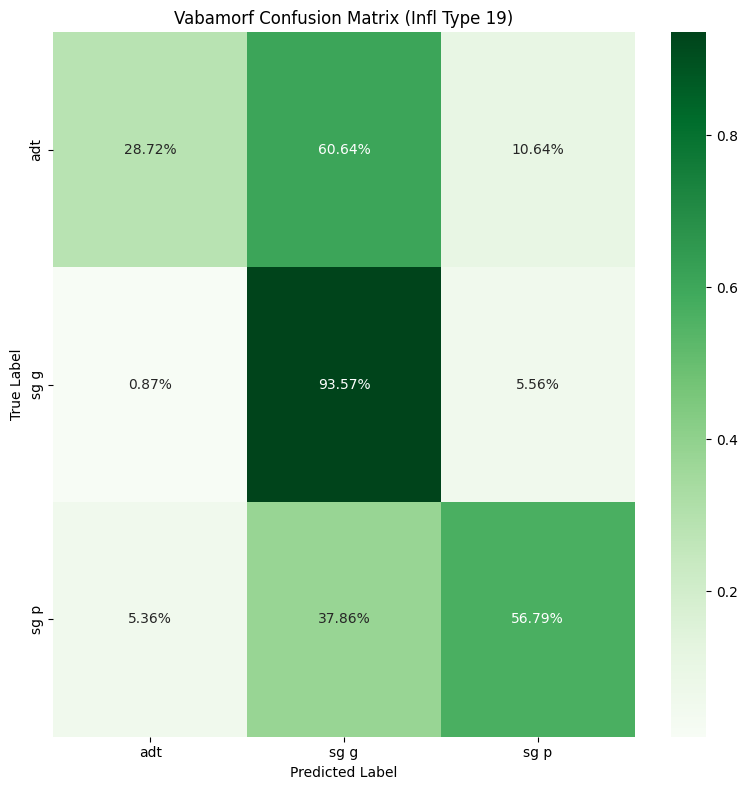

In [ ]:
# Plot confusion matrices per inflection type
for infl_type in results_df["inflection_type"].unique():
    # Filter results for the current inflection type
    results_infl = results_df[results_df["inflection_type"] == infl_type]

    # Generate confusion matrix for BertMorphTagger
    bmt_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["bmt_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    bmt_cm_infl_filtered = bmt_cm_infl[
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["bmt_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Generate confusion matrix for Vabamorf
    vabamorf_cm_infl = sklearn.metrics.confusion_matrix(
        y_true=results_infl["true_label"], y_pred=results_infl["vabamorf_prediction"]
    )

    # Filter confusion matrix to include only labels present in true labels
    vabamorf_cm_infl_filtered = vabamorf_cm_infl[
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        )
    ][
        :,
        np.isin(
            np.unique(results_infl["vabamorf_prediction"]),
            np.unique(results_infl["true_label"]),
        ),
    ]

    # Plot confusion matrix for BertMorphTagger with percentage values
    plt.figure(figsize=(8, 8))
    bmt_cm_infl_normalized = (
        bmt_cm_infl_filtered.astype("float")
        / bmt_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        bmt_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"BertMorphTagger Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(
        "../outputs/plots/homonym/BertMorphTaggerCM_infl_" + str(infl_type), dpi=300
    )
    plt.show()

    # Plot confusion matrix for Vabamorf with percentage values
    plt.figure(figsize=(8, 8))
    vabamorf_cm_infl_normalized = (
        vabamorf_cm_infl_filtered.astype("float")
        / vabamorf_cm_infl_filtered.sum(axis=1)[:, np.newaxis]
    )
    sns.heatmap(
        vabamorf_cm_infl_normalized,
        annot=True,
        fmt=".2%",
        cmap="Greens",
        xticklabels=np.unique(results_infl["true_label"]),
        yticklabels=np.unique(results_infl["true_label"]),
    )
    plt.title(f"Vabamorf Confusion Matrix (Infl Type {infl_type})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig("../outputs/plots/homonym/VabamorfCM_infl_" + str(infl_type), dpi=300)
    plt.show()

## END
